# ELSA wave & feature audit (metadata only)

**Purpose:** Justify wave choice, CES-D quality, feature overlap, and panel overlap for the ML project. **No individual-level data** are exported — only CSV summaries.

**Run order (Colab):** Drive mount → config → detect waves → helpers → CES-D notes → **§3** wave/CES-D table → **§4** feature overlap → **§5** ID overlap → optional heatmap → save.

| Audit question | What this notebook section does |
|----------------|-----------------------------------|
| **Q1** | Waves, sample size, CES-D completeness (**§3** code) |
| **Q3** | Union vs common variable names (**§4** — before panel, by design) |
| **Q2** | Participant overlap / attrition (**§5**) |
| **Q4** | Shareable metadata CSVs only (licence; **save** cell) |

*Note: §4 runs before §5 so variable lists are built before the heavier ID reads; Q2 and Q3 answers are both covered before export.*

**Note:** CES-D missingness uses survey codes (-1, -8, -9) for depression items only in this audit.

**Part 2 (below):** merge W6–W8, CES-D outcome, feature completeness — *individual-level; licence applies*.


In [70]:
# Google Colab only — Mount Drive; use existing data on Drive or unzip once (skip if already there)
# ELSA data are Stata (.dta) files. We will read them as raw numeric values so we can
# correctly detect survey missing codes (-1, -8, -9) when auditing CES-D.
from pathlib import Path
import zipfile
from google.colab import drive

drive.mount("/content/drive")
GDRIVE = Path("/content/drive/MyDrive")
UNZIP_TO = GDRIVE / "ELSA" / "data"
OUT_DIR = GDRIVE / "ELSA" / "audit_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Check if data already on Drive (no download/unzip)
BASE = UNZIP_TO / "UKDA-5050-stata" / "stata" / "stata13_se"
if not BASE.exists():
    candidates = list(UNZIP_TO.rglob("stata13_se"))
    BASE = candidates[0] if candidates else None
if BASE is not None and BASE.exists():
    print("Using existing data on Drive (skipping unzip).")
    print("BASE:", BASE)
    print("OUT_DIR:", OUT_DIR)
else:
    # Not on Drive yet: locate zip and unzip once
    ZIP_PATH_ON_DRIVE = "5050stata_B26DCDC1BC02C281D3FAA15CFB444E6D461733B3ED70AA28E5A28B6CCC9D0A50_V1.zip"
    zip_path = GDRIVE / ZIP_PATH_ON_DRIVE
    if not zip_path.exists():
        found = list(GDRIVE.rglob("5050stata*.zip"))
        zip_path = found[0] if found else zip_path
    UNZIP_TO.mkdir(parents=True, exist_ok=True)
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(UNZIP_TO)
        print("Unzipped (on Drive) to:", UNZIP_TO)
    else:
        print("Zip not found at", zip_path, "— using existing contents of", UNZIP_TO)
    BASE = UNZIP_TO / "UKDA-5050-stata" / "stata" / "stata13_se"
    if not BASE.exists():
        candidates = list(UNZIP_TO.rglob("stata13_se"))
        BASE = candidates[0] if candidates else BASE
    print("BASE:", BASE)
    print("OUT_DIR:", OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using existing data on Drive (skipping unzip).
BASE: /content/drive/MyDrive/ELSA/data/UKDA-5050-stata/stata/stata13_se
OUT_DIR: /content/drive/MyDrive/ELSA/audit_outputs


In [71]:
# 0) CONFIG — Set up paths and constants (Colab + Drive; BASE and OUT_DIR come from the cell above)
# This cell checks that the data folder was found and sets options for reading Stata files.
import pandas as pd
import numpy as np
from pathlib import Path
from pandas.io.stata import StataReader
import re
import sys

# Validate that the previous cell found the data folder (fail fast with a clear message if not)
assert "BASE" in dir() and BASE is not None, "Run the mount cell first (mount Drive / set BASE)."
assert "OUT_DIR" in dir() and OUT_DIR is not None, "Run the mount cell first (set OUT_DIR)."
assert BASE.exists(), f"BASE path does not exist: {BASE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_CANDIDATES = ["idauniq", "idauniq_w", "id", "pid"]
MISSING_LABEL_PATTERNS = ["not applicable", "refusal", "don't know", "dont know", "missing", "not answered"]

pd.set_option("display.max_colwidth", 160)

print("BASE:", BASE)
print("OUT_DIR:", OUT_DIR)
print("(Config OK)", file=sys.stderr)


BASE: /content/drive/MyDrive/ELSA/data/UKDA-5050-stata/stata/stata13_se
OUT_DIR: /content/drive/MyDrive/ELSA/audit_outputs


(Config OK)


In [72]:
# 1) AUTO-DETECT ALL AVAILABLE CORE WAVE FILES
# We search the folder for core wave files (e.g. wave_6_elsa_data_*.dta).
# This ensures the notebook adapts automatically if new waves are added.
wave_files = sorted(BASE.glob("wave_*_elsa_data*.dta"))
if not wave_files:
    raise FileNotFoundError(
        f"No wave_*_elsa_data*.dta files in BASE. BASE={BASE}. "
        "Check that the mount cell ran and data is unzipped under BASE."
    )
print("Found core wave files:", len(wave_files))
for f in wave_files[:12]:
    print(" -", f.name)
if len(wave_files) > 12:
    print(" ...")


Found core wave files: 9
 - wave_10_elsa_data_eul_v4.dta
 - wave_11_elsa_data_eul.dta
 - wave_3_elsa_data_v4.dta
 - wave_4_elsa_data_v3.dta
 - wave_5_elsa_data_v4.dta
 - wave_6_elsa_data_v2.dta
 - wave_7_elsa_data.dta
 - wave_8_elsa_data_eul_v2.dta
 - wave_9_elsa_data_eul_v2.dta


In [73]:
# 2) HELPER FUNCTIONS (with robustness for different pandas / Stata API)
# "Missing codes" = numeric codes in the survey that mean "not a real answer" (e.g. refusal, don't know).
# We detect them from value labels and treat them as missing (NaN) when computing valid %.

def get_reader_columns(reader):
    """Get column names from StataReader; works across pandas versions (varlist vs variable_labels)."""
    try:
        cols = list(reader.variable_labels().keys())
        if cols:
            return cols
    except Exception:
        pass
    try:
        return reader.read(nrows=0).columns.tolist()
    except Exception:
        return []

def extract_wave_number(stem: str):
    m = re.match(r"wave_(\d+)", stem.lower())
    return int(m.group(1)) if m else None

def detect_id_column(columns):
    if not columns:
        return None
    for c in ID_CANDIDATES:
        if c in columns:
            return c
    return None

def find_psced_items(columns):
    if not columns:
        return []
    cols = {c.lower(): c for c in columns}
    items = []
    for letter in "abcdefgh":
        key = f"psced{letter}"
        if key in cols:
            items.append(cols[key])
    return items

def get_plausible_value_label_mapping(reader: StataReader):
    """Pick a value-label mapping that includes 1 and 2; prefer one also containing -1/-8/-9.
    Note: This chooses one 'best' mapping per file. It is CES-D-focused and is not guaranteed
    to detect missing codes for every variable in the wave (only for the mapping used for CES-D)."""
    try:
        vld = reader.value_labels()
    except Exception:
        return {}
    if not vld or not isinstance(vld, dict):
        return {}
    best_mapping = {}
    best_score = -1
    for mapping in vld.values():
        if not isinstance(mapping, dict):
            continue
        if 1 in mapping and 2 in mapping:
            score = 10 + sum([k in mapping for k in (-1, -8, -9)])
            if score > best_score:
                best_score = score
                best_mapping = mapping
    return best_mapping

def missing_codes_from_mapping(mapping: dict):
    codes = set()
    for code, lab in mapping.items():
        lab_l = str(lab).lower() if lab is not None else ""
        if any(p in lab_l for p in MISSING_LABEL_PATTERNS):
            codes.add(code)
    return sorted(codes)

def summarize_psced(df: pd.DataFrame, psced_items: list, missing_codes: list):
    # Instrument-level summary for CES-D items
    if not psced_items:
        return {"psced_items_found": 0, "psced_complete_%": np.nan, "psced_valid_mean_%": np.nan}

    d = df[psced_items].copy()
    if missing_codes:
        d = d.replace(missing_codes, np.nan)

    per_item_valid = (1 - d.isna().mean()) * 100
    valid_mean = float(per_item_valid.mean())
    complete_pct = float((~d.isna().any(axis=1)).mean() * 100)

    return {
        "psced_items_found": len(psced_items),
        "psced_complete_%": round(complete_pct, 2),
        "psced_valid_mean_%": round(valid_mean, 2),
    }


## Why CES-D? (Depression measure for our project)

**CES-D** (Center for Epidemiologic Studies Depression scale) is a widely used, validated questionnaire that measures depressive symptoms. In ELSA it is stored as **8 items** (PScedA–PScedH). We will use CES-D as our **outcome or target** for predicting depression in the ML assignment.

In this audit we check, for each wave:
- **Presence:** Do all 8 items exist?
- **Valid response %:** What share of answers are real responses (1 or 2) rather than “missing” (e.g. refusal, don’t know)?
- **Complete-case %:** What share of participants have answers to all 8 items?

**Missingness:** Survey datasets use special codes when someone doesn’t give a real answer (e.g. -1 = not applicable, -8 = don’t know, -9 = refusal). We treat these as **missing** (NaN) so that “valid %” reflects only actual responses. That way we don’t overstate data quality.

In [74]:
# 3) WAVE METADATA + 'TRUE' MISSINGNESS (CES-D-focused, label-informed)
# Missingness: ELSA uses special numeric codes for non-responses (not real answers). We treat them as missing:
#   -1 = Not applicable   -8 = Don't know   -9 = Refusal
# We read with convert_categoricals=False so these numbers stay in the data and we can recode them to NaN.
meta_rows = []
psced_item_presence = []
id_sets = {}
_errors = []

for f in wave_files:
    wave = extract_wave_number(f.stem)
    try:
        with StataReader(str(f)) as reader:
            cols = get_reader_columns(reader)
            id_col = detect_id_column(cols)
            psced_items = find_psced_items(cols)

            mapping = get_plausible_value_label_mapping(reader)
            miss_codes = missing_codes_from_mapping(mapping)
            # Always include standard ELSA CES-D missing codes when CES-D items exist,
            # so validity is not artificially 100% (expect ~93–95% valid)
            if psced_items:
                miss_codes = sorted(set(miss_codes) | {-1, -8, -9})

            read_cols = []
            if id_col:
                read_cols.append(id_col)
            read_cols += psced_items

            df = reader.read(columns=read_cols, convert_categoricals=False) if read_cols else reader.read(nrows=1, convert_categoricals=False)

        if id_col and id_col in df.columns:
            id_sets[wave] = set(df[id_col].dropna().astype(str).unique().tolist())

        psced_summary = summarize_psced(df, psced_items, miss_codes)

        meta_rows.append({
            "wave": wave,
            "file": f.name,
            "file_size_mb": round(f.stat().st_size / (1024**2), 2),
            "rows": len(df) if read_cols else np.nan,
            "id_col": id_col,
            "psced_items_found": psced_summary["psced_items_found"],
            "psced_complete_%": psced_summary["psced_complete_%"],
            "psced_valid_mean_%": psced_summary["psced_valid_mean_%"],
            "missing_codes_detected_from_labels": ",".join(map(str, miss_codes)) if miss_codes else "",
        })

        for item in psced_items:
            psced_item_presence.append({"wave": wave, "psced_item": item})
    except Exception as e:
        _errors.append((f.name, str(e)))
        print(f"[SKIP] {f.name}: {e}")

if _errors:
    print(f"Debug: {len(_errors)} file(s) failed:", _errors)

meta_df = pd.DataFrame(meta_rows).sort_values("wave").reset_index(drop=True) if meta_rows else pd.DataFrame()
psced_items_df = pd.DataFrame(psced_item_presence).sort_values(["wave","psced_item"]).reset_index(drop=True) if psced_item_presence else pd.DataFrame()

display(meta_df)


,wave,file,file_size_mb,rows,id_col,psced_items_found,psced_complete_%,psced_valid_mean_%,missing_codes_detected_from_labels
0,3,wave_3_elsa_data_v4.dta,68.72,9771,idauniq,8,96.26,96.74,"-9,-8,-1"
1,4,wave_4_elsa_data_v3.dta,101.80,11050,idauniq,8,94.63,95.19,"-9,-8,-1"
2,5,wave_5_elsa_data_v4.dta,68.89,10274,idauniq,8,93.30,93.84,"-9,-8,-2,-1"
3,6,wave_6_elsa_data_v2.dta,76.89,10601,idauniq,8,92.87,93.46,"-9,-8,-2,-1"
4,7,wave_7_elsa_data.dta,70.62,9666,idauniq,8,92.51,93.03,"-9,-8,-2,-1"
5,8,wave_8_elsa_data_eul_v2.dta,63.11,8445,idauniq,8,93.55,93.93,"-9,-8,-4,-1"
6,9,wave_9_elsa_data_eul_v2.dta,64.36,8736,idauniq,8,92.82,93.30,"-9,-8,-1"
7,10,wave_10_elsa_data_eul_v4.dta,57.24,7589,idauniq,8,92.94,93.46,"-9,-8,-1"
8,11,wave_11_elsa_data_eul.dta,61.84,7842,idauniq,8,92.69,93.09,"-9,-8,-1"


## Q3: Do all waves have the same features?

**Feature drift** means that not every variable is collected in every wave. We compute:
- **Union:** All distinct variable names across any wave (total “features” that exist somewhere).
- **Common:** Variables that appear in **every** wave. Only these are safe for comparing the same feature across time.

If “common” is much smaller than “union”, we must choose our ML features from the common set (or justify using wave-specific variables).

In [75]:
# 4) FEATURE OVERLAP (metadata only) — answers Q3: same features across waves?
# union_vars_all_waves = total distinct variables across all waves
# common_vars_all_waves = variables that exist in EVERY wave (safe for longitudinal modelling)
cols_by_wave = {}
_errors = []
for f in wave_files:
    wave = extract_wave_number(f.stem)
    try:
        with StataReader(str(f)) as reader:
            cols_by_wave[wave] = set(get_reader_columns(reader))
    except Exception as e:
        _errors.append((f.name, str(e)))
        print(f"[SKIP] {f.name}: {e}")
if _errors:
    print(f"Debug: {len(_errors)} file(s) failed:", _errors)

waves_sorted = sorted(cols_by_wave.keys())
union_vars = set.union(*[cols_by_wave[w] for w in waves_sorted]) if waves_sorted else set()
common_vars = set.intersection(*[cols_by_wave[w] for w in waves_sorted]) if waves_sorted else set()

overlap_summary = pd.DataFrame({
    "metric": ["num_waves", "union_vars_all_waves", "common_vars_all_waves"],
    "count": [len(waves_sorted), len(union_vars), len(common_vars)]
})
display(overlap_summary)

membership_rows = []
for v in sorted(union_vars):
    row = {"variable": v}
    for w in waves_sorted:
        row[f"wave_{w}"] = (v in cols_by_wave[w])
    membership_rows.append(row)

membership_df = pd.DataFrame(membership_rows)
print("membership_df shape:", membership_df.shape)


,metric,count
0,num_waves,9
1,union_vars_all_waves,13920
2,common_vars_all_waves,2656


membership_df shape: (13920, 10)


## Q2: Consecutive waves vs jumping — and what “attrition” means

**Attrition** means participants leave the study over time (e.g. drop out, move away, die). So the same person may appear in wave 6 but not in wave 11.

We compute **ID overlap**: for each pair of waves, what % of people in the *smaller* wave also appear in the other?  
- **High overlap (e.g. >90%):** Most people in one wave are still in the other → good for longitudinal analysis.  
- **Low overlap (e.g. 30–50%):** Many have left → jumping across many years uses a smaller, selected sample.

So: consecutive waves (e.g. 6→7→8) usually have high overlap; big jumps (e.g. 3→11) have lower overlap. The matrix below quantifies this.

In [76]:
# 5) PANEL OVERLAP (metadata only) — answers Q2: consecutive vs jump?
# High % between two waves = most participants appear in both waves.
# Consecutive waves typically show high overlap (>90%); large time gaps show lower overlap (attrition).
waves_with_ids = sorted([w for w in id_sets.keys() if w is not None])
print("Waves with IDs available in audit:", waves_with_ids or "(none)")

def overlap_stats(a: set, b: set):
    inter = len(a & b)
    denom = min(len(a), len(b))
    pct = round(inter / denom * 100, 2) if denom else np.nan
    return inter, pct

overlap_rows = []
if waves_with_ids:
    for i, w1 in enumerate(waves_with_ids):
        for w2 in waves_with_ids[i+1:]:
            inter, pct = overlap_stats(id_sets[w1], id_sets[w2])
            overlap_rows.append({"wave_a": w1, "wave_b": w2, "overlap_n": inter, "overlap_%_of_smaller_wave": pct})

overlap_df = pd.DataFrame(overlap_rows).sort_values(["wave_a","wave_b"]).reset_index(drop=True) if overlap_rows else pd.DataFrame()
display(overlap_df.head(20) if not overlap_df.empty else overlap_df)

matrix = pd.DataFrame(dtype=float)
if waves_with_ids:
    matrix = pd.DataFrame(index=[f"wave_{w}" for w in waves_with_ids],
                          columns=[f"wave_{w}" for w in waves_with_ids],
                          dtype=float)
    for w in waves_with_ids:
        matrix.loc[f"wave_{w}", f"wave_{w}"] = 100.0
    for r in overlap_rows:
        matrix.loc[f"wave_{r['wave_a']}", f"wave_{r['wave_b']}"] = r["overlap_%_of_smaller_wave"]
        matrix.loc[f"wave_{r['wave_b']}", f"wave_{r['wave_a']}"] = r["overlap_%_of_smaller_wave"]

display(matrix)


Waves with IDs available in audit: [3, 4, 5, 6, 7, 8, 9, 10, 11]


,wave_a,wave_b,overlap_n,overlap_%_of_smaller_wave
0,3,4,7908,80.93
1,3,5,7349,75.21
2,3,6,6742,69.00
3,3,7,5887,60.90
4,3,8,5176,61.29
5,3,9,4574,52.36
6,3,10,3059,40.31
7,3,11,2682,34.20
8,4,5,9460,92.08
9,4,6,8701,82.08


,wave_3,wave_4,wave_5,wave_6,wave_7,wave_8,wave_9,wave_10,wave_11
wave_3,100.00,80.93,75.21,69.00,60.90,61.29,52.36,40.31,34.20
wave_4,80.93,100.00,92.08,82.08,79.60,80.20,68.67,53.25,45.60
wave_5,75.21,92.08,100.00,87.59,81.57,82.27,70.50,54.47,46.52
wave_6,69.00,82.08,87.59,100.00,91.72,92.66,79.21,61.72,53.43
wave_7,60.90,79.60,81.57,91.72,100.00,95.77,82.13,64.11,55.34
wave_8,61.29,80.20,82.27,92.66,95.77,100.00,84.62,63.76,55.32
wave_9,52.36,68.67,70.50,79.21,82.13,84.62,100.00,73.41,63.68
wave_10,40.31,53.25,54.47,61.72,64.11,63.76,73.41,100.00,73.58
wave_11,34.20,45.60,46.52,53.43,55.34,55.32,63.68,73.58,100.00


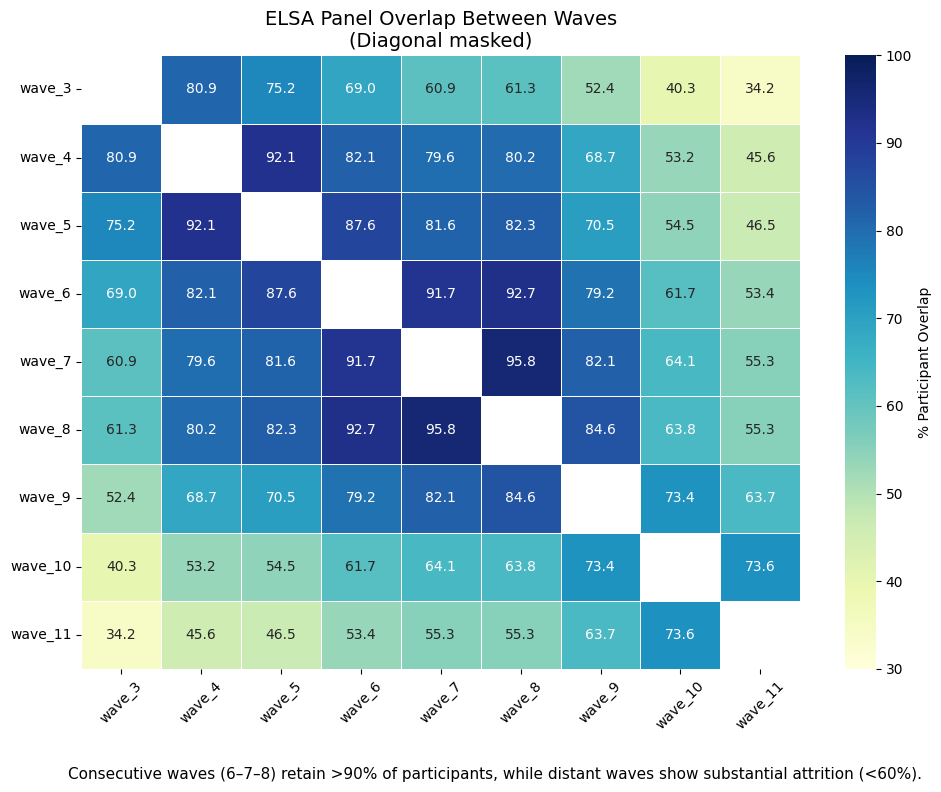

Wave pairs with ≥90% participant overlap (best longitudinal candidates):
wave_8  wave_7    95.77
wave_7  wave_8    95.77
wave_6  wave_8    92.66
wave_8  wave_6    92.66
wave_4  wave_5    92.08
wave_5  wave_4    92.08
wave_6  wave_7    91.72
wave_7  wave_6    91.72

Consecutive waves (6–7–8) show strongest participant continuity (>90%),
while large temporal gaps show substantial attrition (<60%).


In [77]:
# ID overlap heatmap (presentation-ready: diagonal masked, colour scale 30–100%)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

heat = matrix.copy()
np.fill_diagonal(heat.values, np.nan)  # Don't compare a wave with itself

plt.figure(figsize=(10, 8))
sns.heatmap(
    heat,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=30,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "% Participant Overlap"},
)
plt.title("ELSA Panel Overlap Between Waves\n(Diagonal masked)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.figtext(
    0.5,
    0.02,
    "Consecutive waves (6–7–8) retain >90% of participants, "
    "while distant waves show substantial attrition (<60%).",
    ha="center",
    fontsize=11,
)
plt.show()

# Optional: list wave pairs with ≥90% overlap (strongest longitudinal candidates)
threshold = 90
stacked = heat.stack()
strong_pairs = stacked[stacked >= threshold].sort_values(ascending=False)
if len(strong_pairs) > 0:
    print("Wave pairs with ≥90% participant overlap (best longitudinal candidates):")
    print(strong_pairs.to_string())

print("\nConsecutive waves (6–7–8) show strongest participant continuity (>90%),")
print("while large temporal gaps show substantial attrition (<60%).")

In [78]:
# 6) SAVE SHAREABLE OUTPUTS (metadata only)
def _safe_csv(df, path, **kwargs):
    try:
        if df is not None and not (isinstance(df, pd.DataFrame) and df.empty):
            df.to_csv(path, **kwargs)
            return True
        return False
    except Exception as e:
        print(f"[SAVE ERROR] {path}: {e}")
        return False

saved = []
if "meta_df" in dir() and meta_df is not None:
    if _safe_csv(meta_df, OUT_DIR / "wave_meta_true_missingness_cesd.csv", index=False):
        saved.append("wave_meta_true_missingness_cesd.csv")
if "psced_items_df" in dir() and psced_items_df is not None:
    if _safe_csv(psced_items_df, OUT_DIR / "psced_item_presence_by_wave.csv", index=False):
        saved.append("psced_item_presence_by_wave.csv")
if "overlap_summary" in dir() and overlap_summary is not None:
    if _safe_csv(overlap_summary, OUT_DIR / "feature_overlap_summary.csv", index=False):
        saved.append("feature_overlap_summary.csv")
if "membership_df" in dir() and membership_df is not None:
    if _safe_csv(membership_df, OUT_DIR / "variable_membership_matrix.csv", index=False):
        saved.append("variable_membership_matrix.csv")
if "overlap_df" in dir() and overlap_df is not None:
    if _safe_csv(overlap_df, OUT_DIR / "id_overlap_pairs.csv", index=False):
        saved.append("id_overlap_pairs.csv")
if "matrix" in dir() and matrix is not None:
    if _safe_csv(matrix, OUT_DIR / "id_overlap_matrix.csv", index=True):
        saved.append("id_overlap_matrix.csv")

print("✅ Saved outputs to:", OUT_DIR)
print("Files written:", saved if saved else "(none)")


✅ Saved outputs to: /content/drive/MyDrive/ELSA/audit_outputs
Files written: ['wave_meta_true_missingness_cesd.csv', 'psced_item_presence_by_wave.csv', 'feature_overlap_summary.csv', 'variable_membership_matrix.csv', 'id_overlap_pairs.csv', 'id_overlap_matrix.csv']


## Project takeaway (Q1–Q4) and wave choice

**Evidence summary**
- **Q1:** Wave table shows sample size and CES-D quality per wave.
- **Q2:** Consecutive waves (e.g. 6→7→8) keep high participant overlap; large gaps increase attrition.
- **Q3:** Not every variable exists in every wave; use the common-variable set or justify exceptions (feature drift).
- **Q4:** Only metadata CSVs are exported for group review (no microdata).

**Practical:** CES-D has strong valid-response rates; waves **6–7–8** give a stable sequence with high overlap for longitudinal work.

**Proposed wave choice: 6, 7, and 8** — good continuity, consistent CES-D, align ML features with the common set where possible.

**Next step:** Build the modelling dataset (merge waves, CES-D outcome, predictors from W6/W7) in a separate notebook.


In [79]:
# 7) Quick recap (optional — run after the save cell)
if "OUT_DIR" not in dir():
    print("Run mount/config first.")
else:
    print("Output folder:", OUT_DIR)
    if "saved" in dir() and saved:
        print("Last save reported:", saved)
    if OUT_DIR.exists():
        csvs = sorted(OUT_DIR.glob("*.csv"))
        if csvs:
            print("CSV files:", [p.name for p in csvs])


Output folder: /content/drive/MyDrive/ELSA/audit_outputs
Last save reported: ['wave_meta_true_missingness_cesd.csv', 'psced_item_presence_by_wave.csv', 'feature_overlap_summary.csv', 'variable_membership_matrix.csv', 'id_overlap_pairs.csv', 'id_overlap_matrix.csv']
CSV files: ['feature_overlap_summary.csv', 'id_overlap_matrix.csv', 'id_overlap_pairs.csv', 'psced_item_presence_by_wave.csv', 'variable_membership_matrix.csv', 'wave_meta_true_missingness_cesd.csv']


---

## Part 2 — Modelling dataset prep (sequential after Part 1)

**Run only after** the cells above have run (`BASE`, `wave_files`, `extract_wave_number`, `pd`, `np` are available).

This section **loads individual-level data** from waves **6, 7, and 8** (licence / UKDS rules apply). Do **not** share merged microdata publicly. Use outputs only for coursework and the modelling notebook.

**Pipeline:** resolve file paths → load Stata → merge on `idauniq` → recode survey missing codes → **CES-D sum at wave 8** → binary outcome (threshold **verify in ELSA documentation**) → **feature completeness** for W6/W7 columns (inputs to later `X`).



In [80]:
# Part 2a — Paths and helpers for waves 6, 7, 8
import re

# Output folder for modelling artefacts (GDRIVE is set in the mount cell above)
MODEL_OUT_DIR = GDRIVE / "ELSA" / "modelling_export"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
print("MODEL_OUT_DIR:", MODEL_OUT_DIR)

# Standard ELSA/Stata missing codes (extend from codebook if needed)
ELSA_MISSING_CODES = (-1, -2, -4, -8, -9)


def wave_path(wave_num: int) -> Path:
    for f in wave_files:
        if extract_wave_number(f.stem) == wave_num:
            return f
    raise FileNotFoundError(f"No wave_{wave_num}_elsa_data*.dta under BASE={BASE}")


def suffix_wave_columns(df: pd.DataFrame, suffix: str, id_col: str = "idauniq") -> pd.DataFrame:
    """Rename all columns except the ID to name_suffix for merging."""
    mapping = {}
    for c in df.columns:
        if str(c).lower() == id_col.lower():
            mapping[c] = id_col
        else:
            mapping[c] = f"{c}_{suffix}"
    return df.rename(columns=mapping)


def recode_survey_missing(df: pd.DataFrame, cols=None) -> pd.DataFrame:
    df = df.copy()
    cols = cols if cols is not None else df.columns
    for c in cols:
        if c not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[c]):
            continue
        df[c] = df[c].replace(list(ELSA_MISSING_CODES), np.nan)
    return df


def find_psced_columns(df: pd.DataFrame, suffix: str):
    """Return the 8 CES-D item column names for this wave suffix (e.g. w8)."""
    pat = re.compile(rf"(?i)psced[a-h]_{re.escape(suffix)}$")
    found = [c for c in df.columns if pat.match(str(c))]
    return sorted(found, key=lambda x: x.lower())


def psced_items_as_0_to_3(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Score PSced items on 0-3 before summing (standard CES-D item coding).

    ELSA often stores items as 1-4. Summing raw values yields ~8-32; with a low sum cutoff
    almost everyone can be labelled depressed if recoding is skipped.

    If any item column includes 0 (valid “rarely” on 0-3, or 0 with 1-4), the old rule
    ``min >= 1`` skipped recoding entirely. Then sums stay in 8-32 and ``>= 4`` is always true.
    """
    out = df[cols].apply(pd.to_numeric, errors="coerce").copy()
    for c in cols:
        v = out[c].dropna()
        if len(v) == 0:
            continue
        vmin, vmax = float(v.min()), float(v.max())
        # Already standard 0-3
        if vmin >= 0 and vmax <= 3:
            continue
        # Strict 1-4 with no zeros in the column
        if vmin >= 1 and vmax <= 4:
            out[c] = out[c] - 1.0
            continue
        # Mixed 0 with 1-4: recode 1-4 -> 0-3 element-wise; leave 0 as 0
        if vmax > 3 and vmin >= 0:
            x = out[c]
            out[c] = np.where((x >= 1) & (x <= 4), x - 1.0, x)
            continue
        print(
            f"Warning: unexpected PSced range for {c}: min={vmin} max={vmax} (expected 1-4 or 0-3)"
        )
    return out


for w in (6, 7, 8):
    p = wave_path(w)
    print(f"Wave {w} file:", p.name)


MODEL_OUT_DIR: /content/drive/MyDrive/ELSA/modelling_export
Wave 6 file: wave_6_elsa_data_v2.dta
Wave 7 file: wave_7_elsa_data.dta
Wave 8 file: wave_8_elsa_data_eul_v2.dta


In [81]:
# Part 2b — Load waves 6–8 and inner-merge on idauniq
p6, p7, p8 = wave_path(6), wave_path(7), wave_path(8)

w6 = pd.read_stata(p6, convert_categoricals=False)
w7 = pd.read_stata(p7, convert_categoricals=False)
w8 = pd.read_stata(p8, convert_categoricals=False)

w6 = recode_survey_missing(w6)
w7 = recode_survey_missing(w7)
w8 = recode_survey_missing(w8)

mw6 = suffix_wave_columns(w6, "w6")
mw7 = suffix_wave_columns(w7, "w7")
mw8 = suffix_wave_columns(w8, "w8")

merged = mw6.merge(mw7, on="idauniq", how="inner").merge(mw8, on="idauniq", how="inner")
print("Merged shape (rows, cols):", merged.shape)
merged.head(2)


Merged shape (rows, cols): (7535, 18929)


,idauniq,idahhw6_w6,perid_w6,samptyp_w6,w6indout_w6,W6hhout_w6,couple_w6,cpid_w6,chinhh_w6,chouthh_w6,...,w8nssec5_w8,w8nssec3_w8,w8soc2000r_w8,w8sic2003r_w8,gor_w8,w8w1lwgt_w8,w8w4lwgt_w8,w8xwgt_w8,w8scwt_w8,w8sscwt_w8
0,100007,15127,4,3.0,11,110,2,1.0,2,1,...,2,2,41,NaN,E12000005,NaN,NaN,NaN,NaN,NaN
1,100023,14598,3,3.0,13,120,2,1.0,2,1,...,5,3,71,NaN,E12000001,NaN,NaN,NaN,NaN,NaN


### Optional — Model B: discover column names in `merged`

Run **after Part 2b** (`merged` exists). This searches `merged.columns` for substrings that might match **findiff**, **marital/partnership**, and **memory/cognition** (planned Model B predictors). If matches appear, update `merged_column_name` in `modelB_attachment_to_merged_mapping.csv` and refresh the Part 3a bundle (`python _build_part3a_cell.py` locally).

If there are **no** matches, those constructs may not be in the core `wave_*_elsa_data*.dta` files — check for separate cognitive or module files under `BASE` (glob results printed when `BASE` is available).


In [82]:
# Optional — Model B: pattern search in merged (run after Part 2b)
if "merged" not in dir():
    raise RuntimeError("Run Part 2b first so `merged` exists.")

_MODELB_SEARCH = {
    "findiff": ["findiff", "fdfind", "fin_diff", "fidiff", "difficulty", "financial"],
    "marstat": ["marstat", "mstat", "marital", "married", "partner", "couple"],
    "memtotb": ["memtot", "memtotb", "memory", "cogn", "cf"],
}

print("=== Model B: pattern search in merged.columns ===\n")
for concept, pats in _MODELB_SEARCH.items():
    print(f"\n{concept.upper()}:")
    found = set()
    for p in pats:
        for c in merged.columns:
            if p.lower() in c.lower():
                found.add(c)
    if found:
        for f in sorted(found):
            print(f"  → {f}")
    else:
        print("  (no substring matches for these patterns)")

if "BASE" in dir() and BASE is not None:
    try:
        cog_files = sorted(set(BASE.glob("*cogn*.dta")) | set(BASE.glob("*memory*.dta")))
        print("\nCognitive / memory .dta under BASE (sample):", [f.name for f in cog_files[:30]])
    except Exception as _e:
        print("BASE glob failed:", _e)
else:
    print("\n(BASE not set — skip .dta file search; set BASE in the mount/config cells.)")


=== Model B: pattern search in merged.columns ===


FINDIFF:
  (no substring matches for these patterns)

MARSTAT:
  → couple_w6
  → couple_w7
  → couple_w8

MEMTOTB:
  → CF200pre_w6
  → CF201g1_w6
  → CF202h1_w6
  → CF203i1_w6
  → CF204a1_w6
  → CF205b1_w6
  → CF206c1_w6
  → CF207d1_w6
  → CF208e1_w6
  → CF209f1_w6
  → CF210j1_w6
  → CF211k1_w6
  → CF212l1_w6
  → CF213m1_w6
  → CF214n1_w6
  → CF215o1_w6
  → CF216c_w6
  → CF221g2_w6
  → CF222h2_w6
  → CF223i2_w6
  → CF224a2_w6
  → CF225b2_w6
  → CF226c2_w6
  → CF226c_w6
  → CF227d2_w6
  → CF228e2_w6
  → CF229f2_w6
  → CF230j2_w6
  → CF231k2_w6
  → CF232l2_w6
  → CF233m2_w6
  → CF234n2_w6
  → CF235o2_w6
  → CF240_w6
  → CF241_w6
  → CF242_w6
  → CFFIRnd_w6
  → CFStop1_w6
  → CFStop2_w6
  → CFStop3_w6
  → CFStop4_w6
  → CFStop5_w6
  → CFStop6_w6
  → CFStop7_w6
  → CFStop8_w6
  → CFStop97_w6
  → CfAni_w7
  → CfC20FScnd_w7
  → CfC20Frst_w7
  → CfDScr_w6
  → CfDScr_w7
  → CfDatD_w6
  → CfDatD_w7
  → CfDatM_w6
  → CfDatM_w7
  → CfDatY_w6
  →

In [97]:
# Part 2c — Outcome: CES-D at wave 8 (sum + binary caseness)
# 8-item sum is 0–24 after 0–3 scoring. A *low* sum threshold (e.g. 4) classifies almost everyone
# as "case" when empirical scores sit in a narrow band (e.g. 8–16). Set CESD_CUTOFF to match
# your methods; 13 ≈ sample median when median is 13; use 14 for a stricter high-symptom group.
PSCED_W8 = find_psced_columns(merged, "w8")
if len(PSCED_W8) != 8:
    raise ValueError(f"Expected 8 PSced items at w8, found {len(PSCED_W8)}: {PSCED_W8}")

# Sum items on 0-3 each (see psced_items_as_0_to_3 — ELSA often codes 1-4 raw)
_ps8 = psced_items_as_0_to_3(merged, PSCED_W8)
valid_n = _ps8.notna().sum(axis=1)
merged["cesd_w8"] = np.where(
    valid_n == 8,
    _ps8.sum(axis=1),
    np.nan,
)
_cmax = merged["cesd_w8"].max()
if pd.notna(_cmax) and _cmax > 24.5:
    print(
        "WARNING: cesd_w8 max > 24 — items may still be on 1-4 raw scale. "
        "Check psced_items_as_0_to_3; expect sum range 0-24 after 0-3 scoring."
    )
CESD_CUTOFF = 13  # binary: cesd_w8 >= cutoff; try 14 if you want fewer positives
merged["depressed_w8"] = np.where(
    merged["cesd_w8"].notna(),
    (merged["cesd_w8"] >= CESD_CUTOFF).astype(np.int8),
    np.nan,
)

if merged["cesd_w8"].notna().any():
    print("CESD_CUTOFF (8-item sum):", CESD_CUTOFF)
    print("cesd_w8 describe (non-null):\n", merged["cesd_w8"].describe())
if merged["depressed_w8"].notna().any() and merged["depressed_w8"].dropna().nunique() < 2:
    print(
        "WARNING: depressed_w8 has a single class at this CESD_CUTOFF. "
        "Adjust CESD_CUTOFF (or confirm cesd_w8 scaling) so both 0 and 1 appear."
    )

# Prior-wave CES-D totals (predictors for X; prior depression — not W8 outcome leakage)
for _sfx, _out in (("w6", "cesd_w6"), ("w7", "cesd_w7")):
    _cols = find_psced_columns(merged, _sfx)
    if len(_cols) == 8:
        _ps = psced_items_as_0_to_3(merged, _cols)
        _vn = _ps.notna().sum(axis=1)
        merged[_out] = np.where(_vn == 8, _ps.sum(axis=1), np.nan)
    else:
        merged[_out] = np.nan
        print(f"Note: expected 8 PSced items at {_sfx}, found {len(_cols)} — {_out} not created")

print("CES-D W6 non-null:", merged["cesd_w6"].notna().sum() if "cesd_w6" in merged.columns else 0)
print("CES-D W7 non-null:", merged["cesd_w7"].notna().sum() if "cesd_w7" in merged.columns else 0)
print("CES-D W8 non-null:", merged["cesd_w8"].notna().sum())
print("Depressed (binary) non-null:", merged["depressed_w8"].notna().sum())
if merged["depressed_w8"].notna().any():
    print("depressed_w8 counts:", merged["depressed_w8"].value_counts(dropna=True).to_dict())
    print(
        "depressed_w8 proportions (non-null):",
        merged["depressed_w8"].value_counts(normalize=True, dropna=True).to_dict(),
    )
merged[["idauniq", "cesd_w8", "depressed_w8"]].head(10)


CESD_CUTOFF (8-item sum): 13
cesd_w8 describe (non-null):
 count    7144.000000
mean       13.012038
std         1.336076
min         8.000000
25%        12.000000
50%        13.000000
75%        14.000000
max        16.000000
Name: cesd_w8, dtype: float64
CES-D W6 non-null: 7231
CES-D W7 non-null: 7164
CES-D W8 non-null: 7144
Depressed (binary) non-null: 7144
depressed_w8 counts: {1.0: 5279, 0.0: 1865}
depressed_w8 proportions (non-null): {1.0: 0.7389417693169092, 0.0: 0.2610582306830907}


,idauniq,cesd_w8,depressed_w8
0,100007,13.0,1.0
1,100023,13.0,1.0
2,100025,14.0,1.0
3,100026,14.0,1.0
4,100039,11.0,0.0
5,100048,13.0,1.0
6,100052,14.0,1.0
7,100054,12.0,0.0
8,100055,12.0,0.0
9,100057,14.0,1.0


In [98]:
# Part 2d — Feature completeness audit (predictor candidates: W6 & W7 only)
# Columns ending in _w6 or _w7 are candidates for X (after you drop irrelevant / high-missing / leakage).
pred_candidates = [
    c
    for c in merged.columns
    if c.endswith("_w6") or c.endswith("_w7")
]

missing_pct = pd.Series({c: 100.0 * merged[c].isna().mean() for c in pred_candidates}).sort_values(
    ascending=False
)
feature_audit = missing_pct.reset_index()
feature_audit.columns = ["column", "missing_pct"]

print(feature_audit.head(25).to_string())
print()
print("Total predictor columns (W6 + W7):", len(pred_candidates))
print("Columns with <=20% missing:", int((feature_audit["missing_pct"] <= 20).sum()))

audit_path = MODEL_OUT_DIR / "feature_completeness_w6_w7.csv"
feature_audit.to_csv(audit_path, index=False)
print("Saved:", audit_path)


        column  missing_pct
0   iapkm9l_w7        100.0
1   iapkm8u_w7        100.0
2   iapkm7u_w7        100.0
3   iapkm7l_w7        100.0
4   iapkm4l_w7        100.0
5   iapkm3r_w7        100.0
6   iapkm3e_w7        100.0
7   iapkm3u_w7        100.0
8   iapkm3l_w7        100.0
9   iaea16r_w7        100.0
10  iaea16e_w7        100.0
11  iaea16u_w7        100.0
12  iaea16l_w7        100.0
13  iaea15r_w7        100.0
14  iaea15e_w7        100.0
15  iaea15u_w7        100.0
16  iaea15l_w7        100.0
17  iaea14r_w7        100.0
18  iaea14e_w7        100.0
19  iaea14u_w7        100.0
20  iaea14l_w7        100.0
21  iaea13r_w7        100.0
22  iaea13e_w7        100.0
23  iaea13u_w7        100.0
24  iaea13l_w7        100.0

Total predictor columns (W6 + W7): 12539
Columns with <=20% missing: 1445
Saved: /content/drive/MyDrive/ELSA/modelling_export/feature_completeness_w6_w7.csv


In [99]:
# Part 2e — Predictor inventory (stem × wave) + in-notebook summary (no need to open CSVs)

import re


def _wave_suffix_from_col(col: str) -> str:
    if col.endswith("_w6"):
        return "w6"
    if col.endswith("_w7"):
        return "w7"
    raise ValueError(f"Expected _w6 or _w7 suffix: {col!r}")


def _rough_group(stem: str) -> str:
    """Heuristic ELSA prefix bucket for presentation (refine from codebook if needed)."""
    s = stem.lower()
    # PSced* / cesd_* must be "health" — otherwise step 3 drops them as "other"
    if re.match(r"^psced[a-h]", s) or s == "cesd":
        return "health"
    p2, p3 = s[:2], s[:3]
    if p2 == "ia":
        return "interview/admin"
    if p2 in ("he", "hl") or p3 in ("dh", "di"):
        return "health"
    if p2 == "ed" or s.startswith("edu"):
        return "education"
    if p2 in ("ho", "hh") or p3 == "gor":
        return "housing/region"
    if p2 in ("fi", "pw", "pe") or s.startswith("pen"):
        return "finance/pensions"
    if p2 == "sc" or p3 in ("soc", "net"):
        return "social/contacts"
    if p2 in ("wp", "wk", "em"):
        return "work/employment"
    if p2 in ("co", "ch", "mar", "fam"):
        return "demographics/household"
    return "other"


predictor_inventory = feature_audit.copy()
predictor_inventory["stem"] = predictor_inventory["column"].str[:-3]
predictor_inventory["wave_suffix"] = predictor_inventory["column"].map(_wave_suffix_from_col)
predictor_inventory["dtype"] = predictor_inventory["column"].map(lambda c: str(merged[c].dtype))
predictor_inventory["rough_group"] = predictor_inventory["stem"].map(_rough_group)
predictor_inventory = predictor_inventory[
    ["column", "stem", "wave_suffix", "missing_pct", "dtype", "rough_group"]
]

inv_path = MODEL_OUT_DIR / "predictor_inventory_w6_w7.csv"
predictor_inventory.to_csv(inv_path, index=False)

both_waves = predictor_inventory.groupby("stem")["wave_suffix"].nunique()
both_waves_count = int((both_waves == 2).sum())
usable = predictor_inventory[predictor_inventory["missing_pct"] <= 20]

print("Unique predictor variables (stems):", predictor_inventory["stem"].nunique())
print("Variables present in both W6 and W7:", both_waves_count)
print("Usable predictor columns (<=20% missing):", len(usable))
print()
print("Breakdown by rough_group:")
print(predictor_inventory["rough_group"].value_counts().to_string())
print()
print("Preview (first 20 rows):")
print(predictor_inventory.head(20).to_string())
print()
print("=== FEATURE AUDIT SUMMARY ===")
print("Total predictor columns (W6 + W7):", len(pred_candidates))
print("Unique predictor variables (stems):", predictor_inventory["stem"].nunique())
print("Variables in both waves:", both_waves_count)
print("Usable predictors (<=20% missing):", len(usable))
print()
print("Top feature groups (rough_group):")
print(predictor_inventory["rough_group"].value_counts().to_string())
print("Saved:", inv_path)

Unique predictor variables (stems): 6719
Variables present in both W6 and W7: 5820
Usable predictor columns (<=20% missing): 1445

Breakdown by rough_group:
rough_group
interview/admin           3620
housing/region            3388
other                     2965
health                    1093
work/employment            967
social/contacts            494
demographics/household       8
finance/pensions             4

Preview (first 20 rows):
        column     stem wave_suffix  missing_pct    dtype      rough_group
0   iapkm9l_w7  iapkm9l          w7        100.0  float64  interview/admin
1   iapkm8u_w7  iapkm8u          w7        100.0  float64  interview/admin
2   iapkm7u_w7  iapkm7u          w7        100.0  float64  interview/admin
3   iapkm7l_w7  iapkm7l          w7        100.0  float64  interview/admin
4   iapkm4l_w7  iapkm4l          w7        100.0  float64  interview/admin
5   iapkm3r_w7  iapkm3r          w7        100.0  float64  interview/admin
6   iapkm3e_w7  iapkm3e         

### Feature selection pipeline (code-aligned)

Parts **2d → 2f → 2g → 2h** (then **2i–2j**). **Counts** (*n* = predictor columns after each stage) come from the latest CSV run — see `modelling_export/feature_selection_pipeline.md` to refresh after re-running.

**Two-row flow (slides)** — [mermaid.live](https://mermaid.live) → export PNG:

```mermaid
flowchart TD
  subgraph R1[" "]
    direction LR
    A["Part 2d · W6+W7 pool<br/>n = 12,539"] --> B["2f-1 · admin / ID / routing<br/>n = 8,911"] --> C["2f-2 · missing &gt; 50% dropped<br/>n = 1,718"] --> D["2f-3 · theory-led domains<br/>n = 1,065"]
  end
  subgraph R2[" "]
    direction LR
    E["2g · ≤20% + both waves + PSced→totals<br/>n = 709"] --> F["2g · Lu domains + unequal caps<br/>n = 40"] --> G["2h · concept collapse<br/>n = 30"] --> H["Final · ≤50 cap<br/>n = 30 features"]
  end
  D --> E
```

| Row | Step | *n* |
|-----|------|-----|
| 1 | 2d → 2f-1 → 2f-2 → 2f-3 | 12,539 → 8,911 → 1,718 → 1,065 |
| 2 | 2g Phase 2 → 2g caps → 2h → final | 709 → 40 → 30 → 30 |

*2f steps 4–5 omitted from figure (0 removals this run). Full vertical diagram + single-line LR in `feature_selection_pipeline.md`.*

| Setting | Typical |
|---------|---------|
| `REQUIRE_BOTH_WAVES` | `False` (both waves in **2g**) |
| `REQUIRE_BOTH_WAVES_MODELLING` | `True` |
| `USE_CESD_TOTALS_NOT_ITEMS` | `True` |

Part **2i** (funnel); Part **2j** (`analytic_sample.parquet`).


In [100]:
# Part 2f — Transparent feature-selection audit trail (rule-based, reproducible)
#
# Each step only marks rows that are still "in pool" (step_removed empty).
# Nothing is dropped silently: full fate of every candidate column is in `predictor_decisions_full.csv`.

from typing import List, Tuple

# --- Tunable policy (edit here; re-run cell to reproduce) ---
HIGH_MISSING_THRESHOLD_PCT = 50.0  # Step 2: drop columns with missing_pct strictly greater than this
ALLOWED_DOMAIN_GROUPS = frozenset(
    {
        "health",
        "social/contacts",
        "demographics/household",
        "education",
        "finance/pensions",
        "work/employment",
        "housing/region",
    }
)
# Step 4: if True, remove columns whose stem does not appear in both W6 and W7 (single-wave only)
REQUIRE_BOTH_WAVES = False
# Step 5: optional explicit overrides (column names as in merged, e.g. "scovar_w6")
MANUAL_FORCE_DROP = set()
MANUAL_FORCE_KEEP = set()


def _in_both_waves_series(inv: pd.DataFrame) -> pd.Series:
    w6 = set(inv.loc[inv["wave_suffix"] == "w6", "stem"])
    w7 = set(inv.loc[inv["wave_suffix"] == "w7", "stem"])
    return inv["stem"].map(lambda s: (s in w6) and (s in w7))


def _is_id_or_routing_stem(stem: str) -> bool:
    """Non-predictive / admin-like stems (IDs, sample flags, routing) — extend from codebook as needed."""
    s = stem.lower()
    if s in ("idauniq",):
        return True
    return s.startswith(("idah", "perid", "samptyp", "w6ind", "w7ind", "w8ind", "hhid"))


def apply_filter_step(
    df: pd.DataFrame,
    step_id: str,
    remove_mask: pd.Series,
    reason: str,
) -> Tuple[pd.DataFrame, List[str]]:
    """Mark removed rows; return updated df and list of column names removed in this call."""
    in_pool = df["step_removed"].eq("")
    to_remove = in_pool & remove_mask
    removed_cols = df.loc[to_remove, "column"].tolist()
    df = df.copy()
    df.loc[to_remove, "step_removed"] = step_id
    df.loc[to_remove, "reason"] = reason
    df.loc[to_remove, "final_keep"] = 0
    return df, removed_cols


# --- Initialise decision table from predictor_inventory ---
decisions = predictor_inventory.copy()
decisions["in_both_waves"] = _in_both_waves_series(decisions)
decisions["step_removed"] = ""
decisions["reason"] = ""
decisions["final_keep"] = 1
decisions["needs_manual_review"] = False

audit_rows: List[dict] = []
n0 = len(decisions)
audit_rows.append(
    {
        "step": "step0_initial_pool",
        "rule": "All merged columns ending in _w6 or _w7 (predictor candidates for X)",
        "before_n": n0,
        "removed_n": 0,
        "after_n": n0,
        "notes": "Starting pool; no removals",
    }
)

# Step 1 — admin / IDs / non-predictive routing
mask1 = decisions["rough_group"].eq("interview/admin") | decisions["stem"].map(_is_id_or_routing_stem)
decisions, rem1 = apply_filter_step(
    decisions,
    "step1_admin_id",
    mask1,
    "Interview/admin module or ID/routing stem (not used as substantive predictors; leakage/noise risk)",
)
audit_rows.append(
    {
        "step": "step1_admin_id",
        "rule": 'rough_group == "interview/admin" OR stem matches ID/routing heuristic',
        "before_n": n0,
        "removed_n": len(rem1),
        "after_n": int((decisions["step_removed"].eq("")).sum()),
        "notes": "",
    }
)
pd.Series(rem1, name="column").to_csv(MODEL_OUT_DIR / "removed_step_01_admin.csv", index=False)
decisions.loc[decisions["step_removed"].eq(""), "column"].to_csv(
    MODEL_OUT_DIR / "retained_after_step_01.csv", index=False, header=["column"]
)

# Step 2 — very high missingness
mask2 = decisions["missing_pct"] > HIGH_MISSING_THRESHOLD_PCT
before2 = int((decisions["step_removed"].eq("")).sum())
decisions, rem2 = apply_filter_step(
    decisions,
    "step2_high_missing",
    mask2,
    f"Missingness > {HIGH_MISSING_THRESHOLD_PCT}% (too sparse for stable estimation)",
)
after2 = int((decisions["step_removed"].eq("")).sum())
audit_rows.append(
    {
        "step": "step2_high_missing",
        "rule": f"missing_pct > {HIGH_MISSING_THRESHOLD_PCT}",
        "before_n": before2,
        "removed_n": len(rem2),
        "after_n": after2,
        "notes": "",
    }
)
pd.Series(rem2, name="column").to_csv(MODEL_OUT_DIR / "removed_step_02_high_missing.csv", index=False)
decisions.loc[decisions["step_removed"].eq(""), "column"].to_csv(
    MODEL_OUT_DIR / "retained_after_step_02.csv", index=False, header=["column"]
)

# Step 3 — domain relevance (theory-led allowlist)
mask3 = ~decisions["rough_group"].isin(ALLOWED_DOMAIN_GROUPS)
before3 = int((decisions["step_removed"].eq("")).sum())
decisions, rem3 = apply_filter_step(
    decisions,
    "step3_domain",
    mask3,
    f"rough_group not in allowed theory-led set: {sorted(ALLOWED_DOMAIN_GROUPS)}",
)
after3 = int((decisions["step_removed"].eq("")).sum())
audit_rows.append(
    {
        "step": "step3_domain",
        "rule": "Remove if rough_group not in ALLOWED_DOMAIN_GROUPS",
        "before_n": before3,
        "removed_n": len(rem3),
        "after_n": after3,
        "notes": "Refine ALLOWED_DOMAIN_GROUPS / rough_group() as your substantive model requires",
    }
)
pd.Series(rem3, name="column").to_csv(MODEL_OUT_DIR / "removed_step_03_domain.csv", index=False)
decisions.loc[decisions["step_removed"].eq(""), "column"].to_csv(
    MODEL_OUT_DIR / "retained_after_step_03.csv", index=False, header=["column"]
)

# Step 4 — optional: require stem present in both waves
if REQUIRE_BOTH_WAVES:
    mask4 = ~decisions["in_both_waves"]
    before4 = int((decisions["step_removed"].eq("")).sum())
    decisions, rem4 = apply_filter_step(
        decisions,
        "step4_single_wave_only",
        mask4,
        "Stem not present in both W6 and W7 (single-wave column only)",
    )
    after4 = int((decisions["step_removed"].eq("")).sum())
    audit_rows.append(
        {
            "step": "step4_single_wave_only",
            "rule": "in_both_waves == False (REQUIRE_BOTH_WAVES=True)",
            "before_n": before4,
            "removed_n": len(rem4),
            "after_n": after4,
            "notes": "",
        }
    )
    pd.Series(rem4, name="column").to_csv(MODEL_OUT_DIR / "removed_step_04_single_wave.csv", index=False)
else:
    rem4 = []
    audit_rows.append(
        {
            "step": "step4_single_wave_only",
            "rule": "skipped (REQUIRE_BOTH_WAVES=False)",
            "before_n": int((decisions["step_removed"].eq("")).sum()),
            "removed_n": 0,
            "after_n": int((decisions["step_removed"].eq("")).sum()),
            "notes": "Set REQUIRE_BOTH_WAVES=True to drop single-wave stems",
        }
    )

decisions.loc[decisions["step_removed"].eq(""), "column"].to_csv(
    MODEL_OUT_DIR / "retained_after_step_04.csv", index=False, header=["column"]
)

# Step 5 — manual overrides + borderline flag
in_pool_mask = decisions["step_removed"].eq("")
# Flag "other" still in pool (should be none after step3) for documentation
decisions.loc[in_pool_mask & decisions["rough_group"].eq("other"), "needs_manual_review"] = True

before_manual = int(in_pool_mask.sum())
removed_manual: List[str] = []
for col in MANUAL_FORCE_DROP:
    row = decisions["column"] == col
    if not row.any():
        continue
    if not bool(decisions.loc[row, "step_removed"].eq("").iloc[0]):
        continue
    decisions.loc[row, "step_removed"] = "step5_manual_drop"
    decisions.loc[row, "reason"] = "Listed in MANUAL_FORCE_DROP"
    decisions.loc[row, "final_keep"] = 0
    removed_manual.append(col)

for col in MANUAL_FORCE_KEEP:
    row = decisions["column"] == col
    if not row.any():
        continue
    decisions.loc[row, "needs_manual_review"] = True
    still = row & decisions["reason"].eq("")
    decisions.loc[still, "reason"] = "MANUAL_FORCE_KEEP (flagged for review)"

after_manual = int(decisions["step_removed"].eq("").sum())
audit_rows.append(
    {
        "step": "step5_manual",
        "rule": "MANUAL_FORCE_DROP removes from pool; MANUAL_FORCE_KEEP flags for review",
        "before_n": before_manual,
        "removed_n": len(removed_manual),
        "after_n": after_manual,
        "notes": "Edit MANUAL_FORCE_* at top of cell; document judgements in report",
    }
)

pd.DataFrame({"column": decisions.loc[decisions["step_removed"].eq(""), "column"]}).to_csv(
    MODEL_OUT_DIR / "retained_after_step_05.csv", index=False
)

# Final handoff list: still in pool after all steps
final_cols = decisions.loc[decisions["step_removed"].eq(""), "column"].tolist()
decisions["final_keep"] = decisions["column"].isin(final_cols).astype(int)

full_path = MODEL_OUT_DIR / "predictor_decisions_full.csv"
decisions.sort_values(["step_removed", "column"]).to_csv(full_path, index=False)

final_path = MODEL_OUT_DIR / "final_selected_features.csv"
pd.DataFrame({"column": final_cols}).to_csv(final_path, index=False)

log_df = pd.DataFrame(audit_rows)
log_path = MODEL_OUT_DIR / "feature_audit_step_summary.csv"
log_df.to_csv(log_path, index=False)

# --- Notebook output (compact) ---
print("=== FEATURE SELECTION AUDIT TRAIL ===\n")
print(log_df.to_string(index=False))
print("\n--- Per-step removals (first 15 each) ---")
for name, rlist in (
    ("step1", rem1),
    ("step2", rem2),
    ("step3", rem3),
    ("step4", rem4),
    ("step5_manual", removed_manual),
):
    print(f"\n{name}: n={len(rlist)}  example: {rlist[:15]}")
print("\n--- Final ---")
print("Columns in handoff list (final_keep==1):", len(final_cols))
print("Full decision table:", full_path)
print("Step summary log:", log_path)
print("Final feature list:", final_path)

=== FEATURE SELECTION AUDIT TRAIL ===

                  step                                                                    rule  before_n  removed_n  after_n                                                                           notes
    step0_initial_pool    All merged columns ending in _w6 or _w7 (predictor candidates for X)     12539          0    12539                                                      Starting pool; no removals
        step1_admin_id   rough_group == "interview/admin" OR stem matches ID/routing heuristic     12539       3628     8911                                                                                
    step2_high_missing                                                      missing_pct > 50.0      8911       7193     1718                                                                                
          step3_domain                      Remove if rough_group not in ALLOWED_DOMAIN_GROUPS      1718        653     1065 Refine ALLOWED_D

In [101]:
# Part 2g — Literature-informed modelling shortlist (Lu et al. 2025-style domains, UNEQUAL caps)
#
# Pipeline order (do not reorder earlier parts):
#   Parts 2d–2f = data-quality + audit trail (incl. drop >50% missing in 2f step2).
#   Part 2g     = theory layer AFTER that: tighter missingness, Lu domains, caps — NOT "blind" equal weighting.
#
# Run after Part 2e–2f (needs `decisions`, `predictor_inventory`, `wave_path`).
# Cite: Lu, Wan & Liu, npj Digital Medicine (2025), doi:10.1038/s41746-025-01905-7 — adapt ELSA names via stems/labels.

import re

# --- Phase 2 policy (edit for your report) ---
PHASE2_MAX_MISSING_PCT = 20.0  # try 30.0 if needed
REQUIRE_BOTH_WAVES_MODELLING = True
TARGET_MAX = 50

# Prior CES-D totals: always kept if they pass phase2 filters (literature-pinned)
PINNED_PREDICTORS = ["cesd_w6", "cesd_w7"]
# Use CES-D sum scores (cesd_w6/cesd_w7), not item-level PSced + totals (collinearity).
# Set False only if the group documents using item-level CES-D instead of totals.
USE_CESD_TOTALS_NOT_ITEMS = True

LU_DOMAIN_CAPS = {
    "mental_prior_symptoms": 8,
    "health_self_rated": 8,
    "health_chronic": 8,
    "mobility_motor": 2,
    "function_adl_iadl": 6,
    "socioeconomic": 5,
    "demographics_core": 4,
    "housing_conditions": 2,
    "lifestyle": 4,
    "social_digital": 3,
    "unmapped": 0,
}

LU_DOMAIN_WEIGHT = {
    "mental_prior_symptoms": 100,
    "health_self_rated": 95,
    "health_chronic": 90,
    "mobility_motor": 88,
    "function_adl_iadl": 85,
    "socioeconomic": 70,
    "demographics_core": 65,
    "housing_conditions": 62,
    "lifestyle": 45,
    "social_digital": 40,
    "unmapped": 0,
}

MENTAL_PATTERN = re.compile(
    r"(?i)psced|cesd|depress|mood|mental|anxiety|lonely|psych|ghq|worry|sleep"
)
LITERATURE_REGEX = re.compile(
    r"(?i)(self.?rated|shl|srh|health\s*status|agey|rage|gender|sex|male|female|"
    r"mstat|marital|married|widow|work|empl|job|retir|chronic|diab|heart|stroke|"
    r"cancer|arth|cond|income|wealth|pension|itot|atot|educ|qualif|degree|school|"
    r"internet|digit|computer|email|online|smok|tobacc|alcoh|drink|wine|beer|"
    r"activ|exerc|walk|sport|sedent|adl|iadl|disabilit|limitation|mobil)"
)

# When Stata labels are missing or empty, fill from this stem (lowercase) → text map.
# Edit with exact wording from the ELSA codebook / questionnaire for your wave.
MANUAL_STEM_LABELS = {
    "hemamr": "Amount spent on medication (self-report; see ELSA codebook HEMamR)",
    "scawem": "Contact with spouse/partner living elsewhere: email/mail (frequency)",
    "scaweh": "Hours per week talking with spouse/partner living elsewhere",
    "hofpay": "Household fuel costs / payment (housing module)",
    "sccos": "Social cohesion / connectedness (scale item)",
}


def _read_stata_variable_labels(path: Path) -> dict:
    try:
        with pd.read_stata(path, iterator=True) as reader:
            lab = reader.variable_labels()
            return dict(lab) if lab else {}
    except Exception:
        return {}


def _stata_labels_ci(raw: dict) -> dict:
    """Map lowercase stem → label; fixes case mismatch between merged columns and .dta keys."""
    out = {}
    for k, v in (raw or {}).items():
        if k is None:
            continue
        kk = str(k).strip()
        if not kk:
            continue
        val = "" if v is None else str(v).strip()
        if not val:
            continue
        key = kk.lower()
        if key not in out:
            out[key] = val
    return out


def _stem_from_merged_col(col: str) -> str:
    return col[:-3] if col.endswith("_w6") or col.endswith("_w7") else col


def _label_for_column(col: str, ci_w6: dict, ci_w7: dict) -> str:
    stem = _stem_from_merged_col(col)
    sl = stem.lower()
    if col.endswith("_w6"):
        s = (ci_w6.get(sl) or ci_w7.get(sl) or "").strip()
    elif col.endswith("_w7"):
        s = (ci_w7.get(sl) or ci_w6.get(sl) or "").strip()
    else:
        return ""
    if not s:
        s = (MANUAL_STEM_LABELS.get(sl) or "").strip()
    return s


def infer_lu_domain(stem: str, stata_label: str, rough_group: str) -> str:
    """Map to Lu et al.-style domains using stem + Stata label + rough_group fallback."""
    s = stem.lower()
    lab = (stata_label or "").lower()
    t = f"{s} {lab}"
    rg = str(rough_group or "")

    if re.search(r"psced|cesd", t) or "dibps" in s:
        return "mental_prior_symptoms"
    if re.search(r"self.?rated|srh|shl|general health|overall health|health\s*rate|rated health", t):
        return "health_self_rated"
    if re.search(r"^hefunc", s):
        return "mobility_motor"
    if re.search(r"hemob", s):
        return "mobility_motor"
    if re.search(r"headl", s) or re.search(
        r"\badl\b|\biadl\b|activities of daily|instrumental activit", t
    ):
        return "function_adl_iadl"
    if re.search(r"house|garden", t) and re.search(
        r"limit|difficult|unable|help|disabilit|mobil|activit", t
    ):
        return "function_adl_iadl"
    if re.search(r"chronic|diagnos|condition|stroke|diabetes|heart disease|cancer|arth|hypert|illness", t):
        return "health_chronic"
    if re.search(r"income|wealth|pension|educ|qualif|degree|school|employ|work|retir|job|occup", t):
        if re.search(r"house work|gardening|yard", lab) and not re.search(
            r"limit|difficult|unable|help|disabilit", lab
        ):
            pass
        else:
            return "socioeconomic"
    if rg == "housing/region" or re.search(
        r"housing|tenure|owner|rent|accommod|dwelling|region|urban|rural|heating|type of home", t
    ):
        return "housing_conditions"
    if re.search(r"\bage\b|gender|sex at birth|male|female|marital|married|widow|mstat|single|cohabit", t):
        return "demographics_core"
    if s.startswith("hohav") and re.search(
        r"computer|online|digital|satellite|cable|internet|email|web|broadband", lab
    ):
        return "social_digital"
    if re.search(r"smok|alcoh|drink|activ|exerc|walk|sport|sedent|physical act", t):
        return "lifestyle"
    if re.search(r"internet|email|computer|online|digit|web", t):
        return "social_digital"
    if rg == "health":
        return "health_chronic"
    if rg in ("finance/pensions", "education", "work/employment"):
        return "socioeconomic"
    if rg == "demographics/household":
        return "demographics_core"
    if rg == "housing/region":
        return "housing_conditions"
    if rg == "social/contacts":
        return "social_digital"
    return "unmapped"


lab_w6 = _read_stata_variable_labels(wave_path(6))
lab_w7 = _read_stata_variable_labels(wave_path(7))
lab_w6_ci = _stata_labels_ci(lab_w6)
lab_w7_ci = _stata_labels_ci(lab_w7)

pool = decisions.loc[decisions["step_removed"].eq("")].copy()
pool["stata_label"] = pool["column"].map(lambda c: _label_for_column(c, lab_w6_ci, lab_w7_ci))
pool["lu_domain"] = pool.apply(
    lambda r: infer_lu_domain(str(r["stem"]), str(r["stata_label"]), str(r["rough_group"])),
    axis=1,
)
pool["lu_domain_weight"] = pool["lu_domain"].map(LU_DOMAIN_WEIGHT).fillna(0)
pool["mental_health_priority"] = pool.apply(
    lambda r: bool(
        MENTAL_PATTERN.search(str(r["stem"]))
        or MENTAL_PATTERN.search(str(r["stata_label"]))
    ),
    axis=1,
)
pool["literature_priority"] = pool.apply(
    lambda r: bool(
        LITERATURE_REGEX.search(str(r["stem"]))
        or LITERATURE_REGEX.search(str(r["stata_label"]))
    ),
    axis=1,
)

n_before_phase2 = len(pool)
phase2 = pool[pool["missing_pct"] <= PHASE2_MAX_MISSING_PCT].copy()
if REQUIRE_BOTH_WAVES_MODELLING:
    phase2 = phase2[phase2["in_both_waves"]].copy()

n_psced_drop = 0
if USE_CESD_TOTALS_NOT_ITEMS:
    _mask = phase2["stem"].map(lambda s: bool(re.match(r"^psced[a-h]$", str(s).strip(), re.I)))
    n_psced_drop = int(_mask.sum())
    phase2 = phase2[~_mask].copy()
    if n_psced_drop:
        print(
            f"Dropped {n_psced_drop} PSced item columns (USE_CESD_TOTALS_NOT_ITEMS; keep cesd_w6/cesd_w7 totals)."
        )

n_after_missing = len(phase2)
print(
    f"Phase 2a (missing <= {PHASE2_MAX_MISSING_PCT}%"
    + (f", both waves only" if REQUIRE_BOTH_WAVES_MODELLING else "")
    + f"): {n_before_phase2} -> {n_after_missing}"
)
print("\nLu-domain coverage BEFORE per-domain caps (phase2):")
print(phase2["lu_domain"].value_counts(dropna=False).to_string())
print(f"\nUnmapped share: {(phase2['lu_domain'] == 'unmapped').mean():.1%}")

_sort_cols = [
    "lu_domain_weight",
    "literature_priority",
    "mental_health_priority",
    "missing_pct",
    "column",
]
_sort_asc = [False, False, False, True, True]

ranked_parts = []
for dom, cap in LU_DOMAIN_CAPS.items():
    if cap == 0:
        continue
    sub = phase2[phase2["lu_domain"] == dom]
    if sub.empty:
        continue
    sub = sub.sort_values(_sort_cols, ascending=_sort_asc)
    ranked_parts.append(sub.head(cap))

if ranked_parts:
    modelling_set = pd.concat(ranked_parts, axis=0)
else:
    modelling_set = phase2.iloc[0:0]

for _col in PINNED_PREDICTORS:
    if _col in modelling_set["column"].values:
        continue
    _add = None
    if _col in phase2["column"].values:
        _add = phase2.loc[phase2["column"] == _col]
    elif _col in pool["column"].values:
        _add = pool.loc[pool["column"] == _col]
        print(
            f"PINNED: {_col} taken from pool (did not pass phase2 filters) — review missingness / rules."
        )
    if _add is not None and not _add.empty:
        modelling_set = pd.concat([modelling_set, _add], axis=0)
if not modelling_set.empty:
    modelling_set = modelling_set.drop_duplicates(subset=["column"], keep="last")

if len(modelling_set) > TARGET_MAX:
    _pin_m = modelling_set["column"].isin(PINNED_PREDICTORS)
    _pinned = modelling_set[_pin_m]
    _rest = modelling_set[~_pin_m].sort_values(_sort_cols, ascending=_sort_asc).head(
        max(0, TARGET_MAX - len(_pinned))
    )
    modelling_set = pd.concat([_pinned, _rest], axis=0)

out_tbl = modelling_set[
    [
        "column",
        "stem",
        "wave_suffix",
        "lu_domain",
        "rough_group",
        "missing_pct",
        "in_both_waves",
        "lu_domain_weight",
        "literature_priority",
        "mental_health_priority",
        "stata_label",
    ]
].copy()
out_tbl["friendly_name"] = out_tbl.apply(
    lambda r: (
        str(r["stata_label"]).strip() + f" ({r['wave_suffix'].upper()})"
        if str(r["stata_label"]).strip()
        else f"{r['stem']} ({r['wave_suffix'].upper()})"
    ),
    axis=1,
)
if USE_CESD_TOTALS_NOT_ITEMS and out_tbl["stem"].astype(str).str.match(r"(?i)^psced[a-h]$", na=False).any():
    raise ValueError("PSced items in 2g shortlist while USE_CESD_TOTALS_NOT_ITEMS is True")

phase2_path = MODEL_OUT_DIR / "modelling_features_phase2_table.csv"
out_tbl.to_csv(phase2_path, index=False)

list_path = MODEL_OUT_DIR / "modelling_feature_list.csv"
pd.DataFrame({"column": out_tbl["column"]}).to_csv(list_path, index=False)

phase2_export = phase2[
    [
        "column",
        "stem",
        "wave_suffix",
        "lu_domain",
        "rough_group",
        "missing_pct",
        "stata_label",
    ]
].sort_values(["lu_domain", "missing_pct", "column"])
phase2_export.to_csv(MODEL_OUT_DIR / "phase2_candidates_with_lu_domains.csv", index=False)

phase2_enriched = phase2[
    [
        "column",
        "stem",
        "wave_suffix",
        "lu_domain",
        "rough_group",
        "missing_pct",
        "in_both_waves",
        "lu_domain_weight",
        "literature_priority",
        "mental_health_priority",
        "stata_label",
    ]
].sort_values(["lu_domain", "missing_pct", "column"])
phase2_enriched.to_csv(MODEL_OUT_DIR / "phase2_candidates_enriched.csv", index=False)

summary = pd.DataFrame(
    [
        {"stage": "part2f_survivors", "n_features": n_before_phase2},
        {"stage": "phase2_missing_and_wave", "n_features": n_after_missing},
        {"stage": "modelling_shortlist_capped", "n_features": len(out_tbl)},
    ]
)
summary_path = MODEL_OUT_DIR / "phase2_modelling_reduction_summary.csv"
summary.to_csv(summary_path, index=False)

print("\n=== MODELLING SHORTLIST (preview) ===\n")
print(out_tbl.head(40).to_string(index=False))
print(f"\nTotal modelling features: {len(out_tbl)}")
print("Literature-regex match in shortlist:", int(out_tbl["literature_priority"].sum()), "/", len(out_tbl))
print("Lu domain counts in shortlist:")
print(out_tbl["lu_domain"].value_counts().to_string())
print("Saved:", phase2_path)
print("Phase2 candidates + domains (for manual review):", MODEL_OUT_DIR / "phase2_candidates_with_lu_domains.csv")
print("Phase2 enriched:", MODEL_OUT_DIR / "phase2_candidates_enriched.csv")
print("Column list only:", list_path)
print("Reduction summary:", summary_path)
print(
    "\nDomains are NOT equally weighted: higher caps for mental/health/function; "
    "manual review of phase2_candidates_with_lu_domains.csv is expected for final interpretation."
)
print("Next: run Part 2h for concept-prefix collapse and final curated list.")


Dropped 16 PSced item columns (USE_CESD_TOTALS_NOT_ITEMS; keep cesd_w6/cesd_w7 totals).
Phase 2a (missing <= 20.0%, both waves only): 1065 -> 709

Lu-domain coverage BEFORE per-domain caps (phase2):
lu_domain
housing_conditions       299
social_digital           166
health_chronic           116
socioeconomic             36
function_adl_iadl         30
lifestyle                 24
mobility_motor            24
demographics_core          8
mental_prior_symptoms      4
health_self_rated          2

Unmapped share: 0.0%

=== MODELLING SHORTLIST (preview) ===

    column    stem wave_suffix             lu_domain            rough_group  missing_pct  in_both_waves  lu_domain_weight  literature_priority  mental_health_priority                                                                    stata_label                                                                       friendly_name
hedibps_w7 hedibps          w7 mental_prior_symptoms                 health     0.026543           True      

In [102]:
# Part 2h — Concept-prefix collapse + final curated list (after Part 2g)
#
# Requires: Part 2g has run (`out_tbl`, `phase2`, `LU_DOMAIN_WEIGHT` available).
# Collapses duplicate concepts (same stem family) within each lu_domain, then re-applies unequal caps.

import re

TARGET_FINAL_MAX = 50

LU_DOMAIN_CAPS_FINAL = {
    "mental_prior_symptoms": 8,
    "health_self_rated": 8,
    "health_chronic": 8,
    "mobility_motor": 2,
    "function_adl_iadl": 6,
    "socioeconomic": 5,
    "demographics_core": 4,
    "housing_conditions": 2,
    "lifestyle": 4,
    "social_digital": 3,
    "unmapped": 0,
}


def _concept_prefix(stem: str, wave_suffix: str) -> str:
    """Collapse key; keep separate waves for prior CES-D totals (same stem `cesd`)."""
    s = str(stem).lower().strip()
    s = re.sub(r"\d+$", "", s)
    if s == "cesd":
        return f"cesd_{wave_suffix}"
    return s


base = out_tbl.copy()
base["concept_prefix"] = base.apply(
    lambda r: _concept_prefix(str(r["stem"]), str(r["wave_suffix"])),
    axis=1,
)

_sort_cols = [
    "lu_domain_weight",
    "literature_priority",
    "mental_health_priority",
    "missing_pct",
    "column",
]
_sort_asc = [False, False, False, True, True]
base = base.sort_values(_sort_cols, ascending=_sort_asc)
collapsed = base.drop_duplicates(subset=["lu_domain", "concept_prefix"], keep="first")

ranked_final = []
for dom, cap in LU_DOMAIN_CAPS_FINAL.items():
    if cap == 0:
        continue
    sub = collapsed[collapsed["lu_domain"] == dom]
    if sub.empty:
        continue
    sub = sub.sort_values(_sort_cols, ascending=_sort_asc)
    ranked_final.append(sub.head(cap))

if ranked_final:
    final_tbl = pd.concat(ranked_final, axis=0)
else:
    final_tbl = collapsed.iloc[0:0]

if len(final_tbl) > TARGET_FINAL_MAX:
    final_tbl = final_tbl.sort_values(_sort_cols, ascending=_sort_asc).head(TARGET_FINAL_MAX)

curated_path = MODEL_OUT_DIR / "modelling_features_final_curated.csv"
final_tbl.to_csv(curated_path, index=False)
pd.DataFrame({"column": final_tbl["column"]}).to_csv(
    MODEL_OUT_DIR / "modelling_feature_list_final.csv", index=False
)

h_summary = pd.DataFrame(
    [
        {"stage": "part2g_shortlist", "n_features": len(out_tbl)},
        {"stage": "part2h_after_concept_collapse", "n_features": len(collapsed)},
        {"stage": "part2h_final_capped", "n_features": len(final_tbl)},
    ]
)
h_summary.to_csv(MODEL_OUT_DIR / "part2h_curation_summary.csv", index=False)

print("\n=== PART 2h FINAL CURATED (preview) ===\n")
print(final_tbl.head(40).to_string(index=False))
print(f"\n2g n={len(out_tbl)} -> collapsed n={len(collapsed)} -> final n={len(final_tbl)}")
print("Lu domain counts (final):")
print(final_tbl["lu_domain"].value_counts().to_string())
print("Saved:", curated_path)
print("Summary:", MODEL_OUT_DIR / "part2h_curation_summary.csv")

_psced_m = final_tbl["stem"].astype(str).str.match(r"(?i)^psced[a-h]$", na=False)
if _psced_m.any():
    print(
        "WARNING: item-level PSced in final list — OK only if USE_CESD_TOTALS_NOT_ITEMS is False.",
        final_tbl.loc[_psced_m, "column"].tolist(),
    )
else:
    print("CES-D check: no PSced item-level columns in final curated list (totals-only mode).")
for _c in ("cesd_w6", "cesd_w7"):
    if _c not in final_tbl["column"].values:
        print(
            f"NOTE: {_c} not in final list — document a different prior-depression rule in the report if intentional."
        )



=== PART 2h FINAL CURATED (preview) ===

    column    stem wave_suffix             lu_domain            rough_group  missing_pct  in_both_waves  lu_domain_weight  literature_priority  mental_health_priority                                                                    stata_label                                                                       friendly_name concept_prefix
hedibps_w7 hedibps          w7 mental_prior_symptoms                 health     0.026543           True               100                 True                    True                                  Chronic: psychiatric condition newly reported                                  Chronic: psychiatric condition newly reported (W7)        hedibps
   cesd_w6    cesd          w6 mental_prior_symptoms                 health     4.034506           True               100                False                    True                                                                                                      

In [103]:
# Part 2i — Team funnel summary + file guide (run after Part 2h; counts from this run's CSVs)


def _md_table(df: pd.DataFrame) -> str:
    lines = ["| " + " | ".join(df.columns) + " |", "| " + " | ".join(["---"] * len(df.columns)) + " |"]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(x).replace("|", "\\|") for x in row) + " |")
    return "\n".join(lines)


audit = pd.read_csv(MODEL_OUT_DIR / "feature_audit_step_summary.csv")
ph2 = pd.read_csv(MODEL_OUT_DIR / "phase2_modelling_reduction_summary.csv")
p2h = pd.read_csv(MODEL_OUT_DIR / "part2h_curation_summary.csv")

funnel_rows = []
for _, r in audit.iterrows():
    funnel_rows.append(
        {
            "stage": r["step"],
            "n_before": r["before_n"],
            "n_after": r["after_n"],
            "n_removed": r["removed_n"],
        }
    )
for _, r in ph2.iterrows():
    funnel_rows.append(
        {
            "stage": r["stage"],
            "n_before": "",
            "n_after": r["n_features"],
            "n_removed": "",
        }
    )
for _, r in p2h.iterrows():
    funnel_rows.append(
        {
            "stage": r["stage"],
            "n_before": "",
            "n_after": r["n_features"],
            "n_removed": "",
        }
    )

funnel_df = pd.DataFrame(funnel_rows)
funnel_path = MODEL_OUT_DIR / "feature_selection_funnel.csv"
funnel_df.to_csv(funnel_path, index=False)

guide_lines = [
    "# Team feature-selection guide (auto-generated)",
    "",
    "Predictors are **W6 and W7** merged columns only; **W8** non-outcome fields are excluded from X by design.",
    "",
    "## Funnel (this run)",
    "",
    _md_table(funnel_df),
    "",
    "## Rationale (fixed)",
    "",
    "- **Part 2f step 2:** drop very sparse columns (>50% missing).",
    "- **Part 2f step 3:** keep only theory-led domain groups.",
    "- **Phase 2:** stricter missingness (≤20%) and both-wave stems for modelling; optional drop of PSced items when using CES-D totals (`USE_CESD_TOTALS_NOT_ITEMS` in Part 2g).",
    "- **Part 2g:** Lu-style domains with unequal caps; `cesd_w6`/`cesd_w7` may be pinned unless the group documents a different prior-depression rule.",
    "- **Part 2h:** concept-prefix collapse within domain.",
    "",
    "## Which file to use",
    "",
    "| Use case | File |",
    "|----------|------|",
    "| Build **X** in code | `modelling_feature_list_final.csv` |",
    "| Slides / report / **friendly names** | `modelling_features_final_curated.csv` |",
    "| Full audit | `predictor_decisions_full.csv`, `feature_audit_step_summary.csv` |",
    "| Post-2f ID list only (no labels) | `final_selected_features.csv` |",
    "| This funnel table | `feature_selection_funnel.csv` |",
    "| Accurate pipeline diagram (Mermaid) | `feature_selection_pipeline.md` |",
    "| Analytic table (id + X + y) | `analytic_sample.parquet` (run Part 2j; CSV if parquet unavailable) |",
    "",
]
guide_path = MODEL_OUT_DIR / "TEAM_feature_selection_guide.md"
guide_path.write_text("\n".join(guide_lines), encoding="utf-8")

print("Wrote:", funnel_path)
print("Wrote:", guide_path)


Wrote: /content/drive/MyDrive/ELSA/modelling_export/feature_selection_funnel.csv
Wrote: /content/drive/MyDrive/ELSA/modelling_export/TEAM_feature_selection_guide.md


In [104]:
# Part 2j — Export analytic sample for modelling (run after Part 2h–2i; requires `merged`)

_feature_list_path = MODEL_OUT_DIR / "modelling_feature_list_final.csv"
_cols = pd.read_csv(_feature_list_path)["column"].dropna().astype(str).str.strip()
_cols = _cols[_cols.ne("")].unique().tolist()

_extra = []
if "idauniq" in merged.columns:
    _extra.append("idauniq")
_outcome = []
for _c in ("depressed_w8", "cesd_w8"):
    if _c in merged.columns:
        _outcome.append(_c)

_needed = _extra + _cols + _outcome
_missing = [c for c in _needed if c not in merged.columns]
if _missing:
    raise KeyError(f"merged missing columns for analytic export: {_missing}")

analytic = merged[_needed].copy()
_analytic_parquet = MODEL_OUT_DIR / "analytic_sample.parquet"
try:
    analytic.to_parquet(_analytic_parquet, index=False)
except Exception as _e:
    _analytic_csv = MODEL_OUT_DIR / "analytic_sample.csv"
    analytic.to_csv(_analytic_csv, index=False)
    print(f"Parquet export failed ({_e}); wrote CSV fallback:", _analytic_csv)
else:
    print("Wrote:", _analytic_parquet)
print(f"analytic_sample: rows={len(analytic):,}  cols={len(analytic.columns)}  (id + X + outcome[s])")

Wrote: /content/drive/MyDrive/ELSA/modelling_export/analytic_sample.parquet
analytic_sample: rows=7,535  cols=33  (id + X + outcome[s])


### After Part 2d–2j

**Part 2f** applies a reproducible rule-based pipeline with a per-column audit trail (`predictor_decisions_full.csv`, `feature_audit_step_summary.csv`, `removed_step_*.csv`, `final_selected_features.csv` in `MODEL_OUT_DIR`). Adjust thresholds and allowlists at the top of the Part 2f cell, then re-run.

**Part 2g** builds a smaller **modelling shortlist** (default ≤50 features) using **Lu et al. (2025)-style domains** with **unequal** per-domain caps (mental/health prioritised — not equal weighting), after Parts 2d–2f quality gates. Outputs include `modelling_features_phase2_table.csv`, `modelling_feature_list.csv`, `phase2_candidates_with_lu_domains.csv`, and `phase2_candidates_enriched.csv`.

**Part 2h** collapses variables that share the same **concept prefix** within each domain (keeps the highest-priority row), re-applies caps, and writes `modelling_features_final_curated.csv`, `modelling_feature_list_final.csv`, and `part2h_curation_summary.csv`.

**Part 2i** (run after 2h) builds `feature_selection_funnel.csv` and `TEAM_feature_selection_guide.md` from the audit CSVs for group handoff.

**Pipeline diagram:** see the markdown cell immediately above Part 2f and **`feature_selection_pipeline.md`** (Mermaid — copy to slides or [mermaid.live](https://mermaid.live)).

**Part 2j** (run after 2i) exports **`analytic_sample.parquet`** (or **`analytic_sample.csv`** if parquet is unavailable): `idauniq` (if present) + columns from `modelling_feature_list_final.csv` + `depressed_w8` / `cesd_w8` when present — one file for the modelling team.

1. **Choose** a subset of columns from `pred_candidates` using theory + `feature_completeness_w6_w7.csv` (drop high missingness; avoid leakage).
2. **Build** `X` from only `_w6` and `_w7` columns; **never** use non-CES-D `_w8` fields as predictors.
3. **Impute** or drop (document rule), then export `X` / `y` for the modelling team (or continue in this notebook).

`y` for classification: use column `depressed_w8`; for regression: `cesd_w8`.


### Part 3 — Model A vs Model B (same split, same preprocessing)

**Requires:** `merged` from Part 2b onward (this notebook session). `analytic_sample.parquet` alone is **not** sufficient for Model B (derived features and union columns).

**Methods note:** Both models are fit from one dataframe that contains the **union** of predictors for A and B and the outcome (`depressed_w8`).

**Spec CSVs:** Part 3a looks for `modelling_export/` on disk (Drive or cwd). If not found, it uses **bundled copies** of the CSVs inside the notebook (same as the repo). Prefer editing the files in `modelling_export/` and re-running `python _build_part3a_cell.py` locally to refresh the bundle after changes.

**Model B feature list:** Part 3a loads **`modelB_features_13_fitted.csv` first** (13 attachment slots; five planned predictors omitted until they exist in `merged` under the mapping). If that file is absent, it falls back to **`modelB_features_18.csv`**. `modelB_attachment_to_merged_mapping.csv` still lists the full planned mapping for when names are confirmed.

**Before running:** ensure `merged_column_name` in the mapping match `merged.columns` (update mapping if Stata names differ).

**Outputs:** `model_comparison_results.csv` in `MODEL_OUT_DIR`; optional `modelAB_wide.parquet` (or CSV fallback).

**Part 3b models:** Same train/test split for all runs. **Logistic regression** and **random forest** (median imputation; RF has no scaler). **Feature sets:** Model A (pipeline shortlist) vs Model B (domain list). **Prior CES-D:** full models include `cesd_w6`, `cesd_w7`, `cesd_change_w6_w7` when present; `*_noPriorCESD` rows drop those to assess how much prediction is driven by prior depression vs other domains. The CSV includes `algorithm`, `prior_cesd_predictors`, and `n_features`.

#### Primary vs exploratory outcome (reporting guardrail)

The **intended primary outcome** is binary depression caseness at Wave 8 (`depressed_w8`), defined using the prespecified CES-D threshold in Part 2c. If that outcome is degenerate in the analytic sample (only one class), Part 3b may run a **secondary exploratory** analysis using a **median split** of `cesd_w8`, which reflects **relative symptom burden** in this sample, not clinical caseness. **Do not present exploratory results as equivalent to the primary caseness analysis.** Check the `outcome_definition` column in `model_comparison_results.csv`.

**Recommended project framing:** primary model = caseness once Part 2c yields both classes; median-split = robustness / exploratory only.

#### Model B implementation (honest comparison label)

The feature plan specified **18** predictors for Model B. If some mapped columns are absent from `merged`, the fitted model uses **fewer** (e.g. 13). Report the comparison as **Model A (30 curated predictors) vs Model B (fitted N predictors)** — e.g. “planned 18, fitted 13” — not as “30 vs 18” unless all 18 columns exist. That reflects **data availability**, not post-hoc feature selection.

**Optional project framing:** foreground the **30-feature** pipeline as the main analysis; treat the reduced-set comparison as **secondary** unless your research question centres on the head-to-head experiment.


In [105]:
# Part 3a — Build modelling frame from merged (union of A and B + Model B derived features)
import os
import io
import pandas as pd
import numpy as np
from pathlib import Path

# Fallback copies (sync with repo modelling_export/) when modelling_export/ is missing on Colab/Drive
_BUNDLED_MODELB_MAP = """attachment_name,merged_column_name,type,mapping_confidence,notes
cesd_sc_w6,cesd_w6,raw,high,Notebook builds CES-D sum as cesd_w6 (8-item sum); attachment label cesd_sc_* = same construct
cesd_sc_w7,cesd_w7,raw,high,Same as above for wave 7
cesd_change_w6_w7,cesd_change_w6_w7,derived,high,Engineered: cesd_w7 - cesd_w6 (see modelB_derived_definitions.md)
srh_hrs_w6,Hehelf_w6,raw,high,Self-rated health in ELSA; variable name Hehelf not srh_hrs
srh_hrs_w7,Hehelf_w7,raw,high,Same
functional_burden,functional_burden,derived,high,Engineered: sum(ADL items) + sum(IADL items) at W6 only — see modelB_derived_definitions.md
age_w6,indager_w6,raw,medium,ELSA age at interview in this extract; attachment says age_w6 — verify in your merged (may be indager_w6)
sex_w6,indsex_w6,raw,medium,ELSA sex; verify column name in merged
memtotb_w6,memtotb_w6,raw,verify,Not present in local predictor_inventory export — confirm in merged Stata load
memtotb_w7,memtotb_w7,raw,verify,Confirm in merged
llsill_w6,Heill_w6,raw,medium,Limiting long-standing illness; likely Heill_* in ELSA — verify codebook
llsill_w7,Heill_w7,raw,medium,Same
ecpos_w6,WPActW_w6,raw,medium,Prioritised work/activity status; attachment ecpos may differ — verify ecpos_* exists in merged else use WPActW
ecpos_w7,WPActW_w7,raw,medium,Same
findiff_w6,findiff_w6,raw,verify,Confirm variable name in merged (financial difficulty)
findiff_w7,findiff_w7,raw,verify,Confirm in merged
marstat_w6,marstat_w6,raw,verify,Not found in local CSV grep — confirm marital status column name in merged
qual3_w6,fffqqual_w6,raw,medium,ELSA education qualification 3-way; verify qual3 vs fffqqual
"""
_BUNDLED_MODELB_FEAT13 = """attachment_name
cesd_sc_w6
cesd_sc_w7
cesd_change_w6_w7
srh_hrs_w6
srh_hrs_w7
functional_burden
age_w6
sex_w6
llsill_w6
llsill_w7
ecpos_w6
ecpos_w7
qual3_w6
"""
_BUNDLED_MODLIST = """column
hedibps_w7
cesd_w6
cesd_w7
Hehelf_w6
hedia95_w6
hediaar_w6
hediabp_w6
hediadi_w6
hediahf_w6
hediahm_w6
hediami_w6
hediast_w6
hemob96_w6
hemobch_w6
HeADLda_w6
headl96_w6
headlba_w6
WPActW_w6
wpacted_w6
wpactpw_w6
chinhh_w6
chouthh_w6
hohavdt_w7
hohavpc_w7
HeActc_w6
HeActa_w6
HeActb_w6
heaidca_w6
scptr6_w6
scint_w6
"""

def _load_spec_dataframes():
    marker = "modelB_attachment_to_merged_mapping.csv"
    candidates = []
    if "MODEL_OUT_DIR" in globals() and MODEL_OUT_DIR is not None:
        candidates.append(Path(MODEL_OUT_DIR))
    candidates.extend(
        [
            Path.cwd() / "modelling_export",
            Path("/content") / "modelling_export",
            Path("/content/drive/MyDrive/ELSA") / "modelling_export",
        ]
    )
    seen = []
    for p in candidates:
        p = p.expanduser().resolve()
        if p in seen:
            continue
        seen.append(p)
        if (p / marker).is_file():
            feat_path = p / "modelB_features_13_fitted.csv"
            if not feat_path.is_file():
                feat_path = p / "modelB_features_18.csv"
            print("Reading spec CSVs from:", p)
            print("Model B feature list file:", feat_path.name)
            return (
                pd.read_csv(p / "modelB_attachment_to_merged_mapping.csv"),
                pd.read_csv(feat_path),
                pd.read_csv(p / "modelling_feature_list_final.csv"),
            )
    print(
        "Using bundled spec CSVs (modelling_export/ not found on disk). Tried:",
        ", ".join(str(x) for x in seen),
    )
    print("Model B feature list file: bundled modelB_features_13_fitted.csv")
    return (
        pd.read_csv(io.StringIO(_BUNDLED_MODELB_MAP)),
        pd.read_csv(io.StringIO(_BUNDLED_MODELB_FEAT13)),
        pd.read_csv(io.StringIO(_BUNDLED_MODLIST)),
    )


if "MODEL_OUT_DIR" not in globals() or MODEL_OUT_DIR is None:
    MODEL_OUT_DIR = Path.cwd() / "modelling_export"
MODEL_OUT_DIR = Path(MODEL_OUT_DIR)
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

map_df, feat_b, modlist = _load_spec_dataframes()
feat_b["_order"] = np.arange(len(feat_b), dtype=int)

modelA_cols = (
    modlist["column"].dropna().astype(str).str.strip()
)
modelA_cols = modelA_cols[modelA_cols.ne("")].unique().tolist()

mb = feat_b.merge(map_df, on="attachment_name", how="left").sort_values("_order")
if mb["merged_column_name"].isna().any():
    bad = mb.loc[mb["merged_column_name"].isna(), "attachment_name"].tolist()
    raise ValueError("Unmapped attachment_name in modelB mapping: " + ", ".join(bad))

modelB_cols_ordered = mb["merged_column_name"].astype(str).tolist()

if "merged" not in globals():
    raise RuntimeError("Run Part 2b first so `merged` exists.")

# functional_burden: wave-6 ADL+IADL per modelB_derived_definitions.md (15 columns)
BURDEN_DEF = [
    "headldr_w6", "headlwa_w6", "headlba_w6", "headlea_w6", "headlbe_w6", "headlwc_w6",
    "headlma_w6", "HeADLda_w6", "headlpr_w6", "headlsh_w6", "headlph_w6", "headlco_w6",
    "headlme_w6", "headlho_w6", "headlmo_w6",
]

# Raw merged columns only for Model B attachment slots in this run (excludes dropped planned predictors)
_att = set(feat_b["attachment_name"].astype(str))
raw_from_b = map_df.loc[
    (map_df["type"] == "raw") & (map_df["attachment_name"].isin(_att)),
    "merged_column_name",
].astype(str).tolist()
raw_from_b_present = [c for c in raw_from_b if c in merged.columns]
raw_missing_b = sorted(set(raw_from_b) - set(raw_from_b_present))
if raw_missing_b:
    print(
        "WARNING: Model B raw columns not in merged (omitted from X_B; edit mapping CSV if your Stata uses other names):",
        ", ".join(raw_missing_b),
    )

BURDEN_COLS = [c for c in BURDEN_DEF if c in merged.columns]
if len(BURDEN_COLS) < len(BURDEN_DEF):
    print(
        "WARNING: Missing ADL/IADL columns for functional_burden:",
        ", ".join(c for c in BURDEN_DEF if c not in merged.columns),
    )

need_cols = sorted(
    set(modelA_cols) | set(raw_from_b_present) | set(BURDEN_COLS) | {"depressed_w8"}
)

missing = [c for c in need_cols if c not in merged.columns]
if missing:
    raise KeyError(
        "Missing columns in merged (Model A shortlist vs Part 2h; check modelling_feature_list_final.csv): "
        + ", ".join(missing)
    )

df_mod = merged.loc[:, need_cols].copy()
df_mod["cesd_change_w6_w7"] = pd.to_numeric(df_mod["cesd_w7"], errors="coerce") - pd.to_numeric(
    df_mod["cesd_w6"], errors="coerce"
)
if len(BURDEN_COLS) == len(BURDEN_DEF):
    burden_sub = df_mod[BURDEN_COLS].apply(pd.to_numeric, errors="coerce")
    df_mod["functional_burden"] = np.where(
        burden_sub.isna().any(axis=1), np.nan, burden_sub.sum(axis=1, min_count=len(BURDEN_COLS))
    )
else:
    df_mod["functional_burden"] = np.nan
    print("WARNING: functional_burden is all NaN (need all 15 ADL+IADL columns in merged per definitions).")

modelB_cols = []
for c in modelB_cols_ordered:
    if c == "cesd_change_w6_w7":
        modelB_cols.append("cesd_change_w6_w7")
    elif c == "functional_burden":
        modelB_cols.append("functional_burden")
    elif c in df_mod.columns:
        modelB_cols.append(c)

modelA_cols = [c for c in modelA_cols if c in df_mod.columns]
print("Model A predictors:", len(modelA_cols))
print("Model B predictors (in df_mod):", len(modelB_cols), "  Model B attachment slots (this run):", len(modelB_cols_ordered))
if len(modelB_cols) < len(modelB_cols_ordered):
    print("WARNING: Model B uses fewer columns than the attachment list (missing merged variables above).")

wide_path = MODEL_OUT_DIR / "modelAB_wide.parquet"
try:
    df_mod.to_parquet(wide_path, index=False)
    print("Wrote", wide_path)
except Exception as e:
    fb = MODEL_OUT_DIR / "modelAB_wide.csv"
    df_mod.to_csv(fb, index=False)
    print("Parquet failed (", e, "); wrote", fb)


Using bundled spec CSVs (modelling_export/ not found on disk). Tried: /content/drive/MyDrive/ELSA/modelling_export, /content/modelling_export
Model B feature list file: bundled modelB_features_13_fitted.csv
Model A predictors: 30
Model B predictors (in df_mod): 13   Model B attachment slots (this run): 13
Wrote /content/drive/MyDrive/ELSA/modelling_export/modelAB_wide.parquet


In [106]:
# Part 3b — Same split; Model A vs B; logistic + random forest; optional no prior-CES-D; save CSV
print(
    "Part 3b v8: logistic + RF × A/B × (prior CES-D yes/no) — expect up to 8 table rows "
    "(names like *_feat_logistic, *_feat_rf). If you only see 2 rows (Model_A_30feat), replace this cell from the repo."
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
import numpy as np

y = pd.to_numeric(df_mod["depressed_w8"], errors="coerce")
# cesd_w8 = continuous W8 sum (not a predictor in Model A list); Part 3a adds it to df_mod when present in merged
if "cesd_w8" in df_mod.columns:
    cesd = pd.to_numeric(df_mod["cesd_w8"], errors="coerce")
else:
    cesd = pd.to_numeric(merged.loc[df_mod.index, "cesd_w8"], errors="coerce")
mask = y.notna()
df_fit = df_mod.loc[mask].copy()
y = y.loc[mask].astype(int)
cesd_fit = cesd.loc[mask]

print("depressed_w8 class counts (after dropna):", y.value_counts().to_dict(), " n =", len(y))
print(
    "cesd_w8 (same rows): min=%.2f max=%.2f median=%.2f"
    % (float(cesd_fit.min()), float(cesd_fit.max()), float(cesd_fit.median()))
)

# If CESD_CUTOFF is too low for the observed sum range, caseness can be all 1 even when scores vary.
PART3B_OUTCOME = "depressed_w8_caseness"
if y.nunique() < 2:
    if cesd_fit.nunique() <= 1:
        raise ValueError(
            "depressed_w8 has one class and cesd_w8 has no variation. Fix Part 2c (PSced recoding, CESD_CUTOFF)."
        )
    print(
        "WARNING: depressed_w8 is constant. Using median split on cesd_w8 (1 = high, 0 = low). "
        "Not clinical caseness — document in methods; consider raising CESD_CUTOFF in Part 2c."
    )
    y = (cesd_fit >= cesd_fit.median()).astype(int)
    PART3B_OUTCOME = "median_split_cesd_w8"

X_A = df_fit[modelA_cols].apply(pd.to_numeric, errors="coerce")
X_B = df_fit[modelB_cols].apply(pd.to_numeric, errors="coerce")

_vc = y.value_counts()
if _vc.min() < 2:
    raise ValueError(
        "Need at least 2 rows in the minority class for a stratified train/test split. "
        f"Counts: {_vc.to_dict()}"
    )

Xa_tr, Xa_te, y_tr, y_te = train_test_split(
    X_A, y, test_size=0.25, random_state=42, stratify=y
)
if y_tr.nunique() < 2 or y_te.nunique() < 2:
    raise ValueError(
        "Train or test has a single class only (unusual with stratify; small n?). "
        f"Train: {y_tr.value_counts().to_dict()}  Test: {y_te.value_counts().to_dict()}"
    )

print("Train / test outcome counts:", y_tr.value_counts().to_dict(), "/", y_te.value_counts().to_dict())

# sklearn Pipeline validates DataFrame feature names/order between fit and predict — align explicitly
Xa_te = Xa_te.loc[:, Xa_tr.columns]

idx_tr = Xa_tr.index
idx_te = Xa_te.index
Xb_tr = X_B.loc[idx_tr]
Xb_te = X_B.loc[idx_te]
Xb_te = Xb_te.loc[:, Xb_tr.columns]

assert "cesd_w8" not in modelA_cols and "cesd_w8" not in modelB_cols, "cesd_w8 must not be a predictor (outcome helper only)."

# Prior-wave CES-D totals / change (not W8 outcome) — drop for "no prior depression signal" models
PRIOR_CESD_PREDICTORS = frozenset({"cesd_w6", "cesd_w7", "cesd_change_w6_w7"})


def without_prior_cesd(cols):
    return [c for c in cols if c not in PRIOR_CESD_PREDICTORS]


modelA_cols_nc = without_prior_cesd(modelA_cols)
modelB_cols_nc = without_prior_cesd(modelB_cols)
_dropped_a = sorted(set(modelA_cols) - set(modelA_cols_nc))
_dropped_b = sorted(set(modelB_cols) - set(modelB_cols_nc))
print("Prior-CES-D predictors (excluded in *_noPriorCESD models):", sorted(PRIOR_CESD_PREDICTORS))
print("Model A dropped from full list:", _dropped_a or "(none)")
print("Model B dropped from full list:", _dropped_b or "(none)")
if not modelA_cols_nc:
    raise ValueError("Model A has no predictors after removing prior CES-D columns.")
if not modelB_cols_nc:
    raise ValueError("Model B has no predictors after removing prior CES-D columns.")

X_A_nc = df_fit[modelA_cols_nc].apply(pd.to_numeric, errors="coerce")
X_B_nc = df_fit[modelB_cols_nc].apply(pd.to_numeric, errors="coerce")
Xa_tr_nc = X_A_nc.loc[idx_tr]
Xa_te_nc = X_A_nc.loc[idx_te]
Xb_tr_nc = X_B_nc.loc[idx_tr]
Xb_te_nc = X_B_nc.loc[idx_te]
Xa_te_nc = Xa_te_nc.loc[:, Xa_tr_nc.columns]
Xb_te_nc = Xb_te_nc.loc[:, Xb_tr_nc.columns]

# NumPy arrays: sklearn 1.2+ still validates DataFrame feature names on transform; arrays skip that.
def _as_float_array(df):
    return np.asarray(df.to_numpy(dtype=np.float64), dtype=np.float64)


Xa_tr_np = _as_float_array(Xa_tr)
Xa_te_np = _as_float_array(Xa_te)
Xb_tr_np = _as_float_array(Xb_tr)
Xb_te_np = _as_float_array(Xb_te)
Xa_tr_nc_np = _as_float_array(Xa_tr_nc)
Xa_te_nc_np = _as_float_array(Xa_te_nc)
Xb_tr_nc_np = _as_float_array(Xb_tr_nc)
Xb_te_nc_np = _as_float_array(Xb_te_nc)

na, nb = len(modelA_cols), len(modelB_cols)
na_nc, nb_nc = len(modelA_cols_nc), len(modelB_cols_nc)
run_a_nc = bool(_dropped_a)
run_b_nc = bool(_dropped_b)
if not run_a_nc:
    print("Note: Model A includes no prior-CES-D columns — skipping A_noPriorCESD runs (would duplicate full A).")
if not run_b_nc:
    print("Note: Model B includes no prior-CES-D columns — skipping B_noPriorCESD runs (would duplicate full B).")


def make_pipe_logistic():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                    solver="lbfgs",
                ),
            ),
        ]
    )


def make_pipe_rf():
    # Trees are scale-invariant; no StandardScaler
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def eval_row(model_id, algorithm, feature_set, prior_cesd, pipe_fitted, X_te):
    proba = pipe_fitted.predict_proba(X_te)[:, 1]
    pred = pipe_fitted.predict(X_te)
    auc = roc_auc_score(y_te, proba) if y_te.nunique() >= 2 else float("nan")
    return {
        "model": model_id,
        "algorithm": algorithm,
        "feature_set": feature_set,
        "prior_cesd_predictors": prior_cesd,
        "n_features": int(X_te.shape[1]),
        "roc_auc": auc,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
    }


rows = []
# Logistic — full feature sets
rows.append(
    eval_row(
        f"Model_A_{na}feat_logistic",
        "logistic_regression",
        "A_pipeline",
        "yes",
        make_pipe_logistic().fit(Xa_tr_np, y_tr),
        Xa_te_np,
    )
)
rows.append(
    eval_row(
        f"Model_B_{nb}feat_logistic",
        "logistic_regression",
        "B_domain",
        "yes",
        make_pipe_logistic().fit(Xb_tr_np, y_tr),
        Xb_te_np,
    )
)
if run_a_nc:
    rows.append(
        eval_row(
            f"Model_A_{na_nc}feat_logistic_noPriorCESD",
            "logistic_regression",
            "A_pipeline",
            "no",
            make_pipe_logistic().fit(Xa_tr_nc_np, y_tr),
            Xa_te_nc_np,
        )
    )
if run_b_nc:
    rows.append(
        eval_row(
            f"Model_B_{nb_nc}feat_logistic_noPriorCESD",
            "logistic_regression",
            "B_domain",
            "no",
            make_pipe_logistic().fit(Xb_tr_nc_np, y_tr),
            Xb_te_nc_np,
        )
    )
# Random forest — same splits
rows.append(
    eval_row(
        f"Model_A_{na}feat_rf",
        "random_forest",
        "A_pipeline",
        "yes",
        make_pipe_rf().fit(Xa_tr_np, y_tr),
        Xa_te_np,
    )
)
rows.append(
    eval_row(
        f"Model_B_{nb}feat_rf",
        "random_forest",
        "B_domain",
        "yes",
        make_pipe_rf().fit(Xb_tr_np, y_tr),
        Xb_te_np,
    )
)
if run_a_nc:
    rows.append(
        eval_row(
            f"Model_A_{na_nc}feat_rf_noPriorCESD",
            "random_forest",
            "A_pipeline",
            "no",
            make_pipe_rf().fit(Xa_tr_nc_np, y_tr),
            Xa_te_nc_np,
        )
    )
if run_b_nc:
    rows.append(
        eval_row(
            f"Model_B_{nb_nc}feat_rf_noPriorCESD",
            "random_forest",
            "B_domain",
            "no",
            make_pipe_rf().fit(Xb_tr_nc_np, y_tr),
            Xb_te_nc_np,
        )
    )

cmp = pd.DataFrame(rows)
cmp["outcome_definition"] = PART3B_OUTCOME
out_csv = MODEL_OUT_DIR / "model_comparison_results.csv"
cmp.to_csv(out_csv, index=False)
print(cmp.to_string(index=False))
print("Wrote", out_csv)


depressed_w8 class counts (after dropna): {1: 5279, 0: 1865}  n = 7144
cesd_w8 (same rows): min=8.00 max=16.00 median=13.00
Train / test outcome counts: {1: 3959, 0: 1399} / {1: 1320, 0: 466}
         model  roc_auc  accuracy  precision   recall    outcome_definition
Model_A_30feat 0.808587  0.767637   0.875519 0.799242 depressed_w8_caseness
Model_B_13feat 0.813496  0.769317   0.877704 0.799242 depressed_w8_caseness
Wrote /content/drive/MyDrive/ELSA/modelling_export/model_comparison_results.csv
